# Population state-space analysis — Final Version

This notebook merges the best of two prior versions:

**From the visual-final version (added back)**
- Full-session all-condition centroid map (Section 11)
- Representational Dissimilarity Matrix across all conditions (Section 11)
- Within-phase multiclass decoding for Pre and Post (Section 10)
- Circular-shift block permutation test for single-neuron significance (Section 7)
- Time-resolved centroid distance and distance-from-pre for trajectories (Section 6)

**From the revised version (preserved)**
- Fully standalone — no external utils.py dependency
- Within-phase decoding always reported as BOTH binwise CV and grouped CV
- Explicit cross-phase sniff transfer metric (train Pre, test Post and vice versa)
- Left / right visual-field decomposition (Section 8)
- Interpretation guardrails at the end of each section
- Compact summary tables (Section 12)

---

## Global interpretation guardrails (apply throughout)

- **Bin-level decoding** is a separability probe, not an estimate of independent-trial
  generalisation. Temporally autocorrelated bins inflate accuracy.
- **Grouped CV** reduces that inflation but does not eliminate it (still a single session).
- **Attack trajectories** are onset-referenced dynamics inside clustered aggressive
  episodes — not isolated single-event impulse responses.
- **Pre → Post changes** are session-level remapping; the causal mechanism is open
  (learning, arousal, adaptation, satiety, session non-stationarity are all possible).
- **Single-neuron permutation results** are descriptive effect summaries within this
  session, not cell typing.

In [1]:
# =============================================================================
# SECTION 0 · Imports
# =============================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import cdist
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (needed for 3-D scatter)

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load dataset

Expected files in the working directory (or set DATA_DIR below):
- `neuralData.mat`
- `peripheralData.mat`
- `behaviorData.mat`

Fully standalone — no external utils.py required.

In [2]:
# =============================================================================
# SECTION 1 · Data loading helpers  (standalone, no external utils.py)
# =============================================================================

def _to_str(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    if isinstance(x, np.ndarray) and x.size == 1:
        return _to_str(x.item())
    return str(x)


def cell_to_dict(cell_like):
    """Convert MATLAB cell array (N×2: {name, value}) to Python dict."""
    arr = np.asarray(cell_like, dtype=object)
    arr = np.squeeze(arr)
    out = {}
    if arr.ndim == 2 and arr.shape[-1] == 2:
        iterable = arr
    elif arr.ndim == 1 and len(arr) > 0 and isinstance(arr[0], (list, tuple, np.ndarray)):
        iterable = arr
    else:
        raise ValueError(f"Unsupported cell array shape: {arr.shape}")
    for row in iterable:
        name  = _to_str(row[0])
        value = np.asarray(row[1]).squeeze()
        out[name] = (value.astype(float)
                     if np.issubdtype(np.asarray(value).dtype, np.number)
                     else value)
    return out


def load_dataset(data_dir="."):
    data_dir = Path(data_dir)
    N      = sio.loadmat(data_dir / "neuralData.mat")
    P      = sio.loadmat(data_dir / "peripheralData.mat")
    B      = sio.loadmat(data_dir / "behaviorData.mat")
    FR     = np.asarray(N["FR"], dtype=float)
    periph = cell_to_dict(P["peripheralData"])
    behav  = cell_to_dict(B["behaviorData"])
    return FR, periph, behav


DATA_DIR = Path(".")          # ← change if needed
FR, periph, behav = load_dataset(DATA_DIR)

fs = 50.0          # Hz
dt = 1.0 / fs
n_neurons, n_timebins = FR.shape
t_sec = np.arange(n_timebins) / fs
t_min = t_sec / 60.0

print(f"Neural data : {n_neurons} neurons × {n_timebins} bins "
      f"({n_timebins / fs / 60:.1f} min at {fs} Hz)")

# ── Peripheral signals ────────────────────────────────────────────────
gate_open   = periph["gateOpen"].astype(bool)
white_light = periph["whiteLight"].astype(bool)
sniff_urine = periph["ctBudSniff"].astype(bool)
lick_milk   = periph["lickMilk"].astype(bool)
lick_empty  = periph["lickEmpty"].astype(bool)

# ── Behaviour signals ─────────────────────────────────────────────────
attack_left   = behav["attackOfIntLeft"].astype(bool)
attack_right  = behav["attackOfIntRight"].astype(bool)
attack_dark   = behav["attackDark"].astype(bool)
attack        = attack_left | attack_right | attack_dark

submission_left  = behav["submissionSignFromIntLeft"].astype(bool)
submission_right = behav["submissionSignFromIntRight"].astype(bool)
submission       = submission_left | submission_right

chase_left  = behav.get("chaseOfIntLeft",  np.zeros(n_timebins, bool)).astype(bool)
chase_right = behav.get("chaseOfIntRight", np.zeros(n_timebins, bool)).astype(bool)
chase       = chase_left | chase_right

Neural data : 218 neurons × 60000 bins (20.0 min at 50.0 Hz)


## 2. Preprocessing

In [3]:
# =============================================================================
# SECTION 2 · Preprocessing
# =============================================================================
def smooth_and_zscore_fr(FR, fs=50.0, smooth_width_ms=200.0):
    smoothWidth_bins = round((smooth_width_ms / 1000.0) * fs)  # = 10
    sigma_bins = smoothWidth_bins / 3                           # = 3.0，和MATLAB一致
    FR_smooth = gaussian_filter1d(FR.astype(float), sigma=sigma_bins,
                                  axis=1, mode="nearest")
    mu = FR_smooth.mean(axis=1, keepdims=True)
    sd = FR_smooth.std(axis=1,  keepdims=True)
    sd[sd == 0] = 1.0
    FRz = (FR_smooth - mu) / sd
    FRz[~np.isfinite(FRz)] = 0.0
    return FR_smooth, FRz

def build_phase_masks_from_paradigm(
    n_timebins, fs=50.0,
    gate_open_time_s=5 * 60 + 45,
    white_duration_s=5 * 60,
    dark_duration_s=5 * 60,
):
    """Hard-code paradigm phase boundaries from known timing."""
    n         = int(n_timebins)
    pre_end   = min(int(round(gate_open_time_s * fs)), n)
    white_end = min(int(round((gate_open_time_s + white_duration_s) * fs)), n)
    dark_end  = min(int(round((gate_open_time_s + white_duration_s + dark_duration_s) * fs)), n)

    pre       = np.zeros(n, dtype=bool); pre[:pre_end]              = True
    white_agg = np.zeros(n, dtype=bool); white_agg[pre_end:white_end] = True
    dark_agg  = np.zeros(n, dtype=bool); dark_agg[white_end:dark_end] = True
    post      = np.zeros(n, dtype=bool); post[dark_end:]            = True

    return {"Pre": pre, "WhiteAgg": white_agg, "DarkAgg": dark_agg, "Post": post}


FR_smooth, FRz  = smooth_and_zscore_fr(FR, fs=fs, smooth_width_ms=200)
phase_masks     = build_phase_masks_from_paradigm(n_timebins, fs=fs)

print("Phase bin counts:")
for nm, m in phase_masks.items():
    print(f"  {nm:10s}: {m.sum():6d} bins  ({m.sum() / fs / 60:.2f} min)")

Phase bin counts:
  Pre       :  17250 bins  (5.75 min)
  WhiteAgg  :  15000 bins  (5.00 min)
  DarkAgg   :  15000 bins  (5.00 min)
  Post      :  12750 bins  (4.25 min)


## 3. Session overview

In [4]:
# =============================================================================
# SECTION 3 · Session overview
# =============================================================================

def bouts_summary(mask, fs=50.0, name=None):
    mask  = np.asarray(mask).astype(bool)
    diff  = np.diff(np.concatenate([[0], mask.astype(int), [0]]))
    starts = np.flatnonzero(diff ==  1)
    ends   = np.flatnonzero(diff == -1)
    durs   = (ends - starts) / fs
    row = {
        "n_bins":         int(mask.sum()),
        "n_bouts":        len(starts),
        "total_dur_s":    float(durs.sum())    if len(durs) else 0.0,
        "mean_bout_s":    float(durs.mean())   if len(durs) else 0.0,
        "median_bout_s":  float(np.median(durs)) if len(durs) else 0.0,
    }
    if name is not None:
        row = {"variable": name, **row}
    return row


behaviour_masks = {
    "attack":           attack,
    "attack_left":      attack_left,
    "attack_right":     attack_right,
    "attack_dark":      attack_dark,
    "submission":       submission,
    "submission_left":  submission_left,
    "submission_right": submission_right,
    "chase":            chase,
    "sniff_urine":      sniff_urine,
    "lick_milk":        lick_milk,
    "lick_empty":       lick_empty,
}

behaviour_summary_df = pd.DataFrame(
    [bouts_summary(m, fs=fs, name=nm) for nm, m in behaviour_masks.items()]
).sort_values("total_dur_s", ascending=False)
display(behaviour_summary_df.round(3))

# Phase × behaviour bin count table
phase_count_rows = []
for nm, mask in behaviour_masks.items():
    row = {"variable": nm}
    for pnm, pm in phase_masks.items():
        row[pnm] = int((mask & pm).sum())
    row["total"] = int(mask.sum())
    phase_count_rows.append(row)

phase_count_df = pd.DataFrame(phase_count_rows).sort_values("total", ascending=False)
display(phase_count_df)

,variable,n_bins,n_bouts,total_dur_s,mean_bout_s,median_bout_s
4,submission,5561,55,111.2200,2.0220,0.7400
5,submission_left,4967,36,99.3400,2.7590,1.4800
0,attack,3856,106,77.1200,0.7280,0.5700
3,attack_dark,2000,68,40.0000,0.5880,0.4000
8,sniff_urine,1777,38,35.5400,0.9350,0.5700
1,attack_left,1349,26,26.9800,1.0380,0.8900
9,lick_milk,1029,9,20.5800,2.2870,0.2200
6,submission_right,594,19,11.8800,0.6250,0.3000
10,lick_empty,580,66,11.6000,0.1760,0.1000
2,attack_right,507,12,10.1400,0.8450,0.7400


,variable,Pre,WhiteAgg,DarkAgg,Post,total
4,submission,0,5561,0,0,5561
5,submission_left,0,4967,0,0,4967
0,attack,0,1856,1175,825,3856
3,attack_dark,0,0,1175,825,2000
8,sniff_urine,883,0,0,894,1777
1,attack_left,0,1349,0,0,1349
9,lick_milk,959,0,0,70,1029
6,submission_right,0,594,0,0,594
10,lick_empty,174,0,0,406,580
2,attack_right,0,507,0,0,507


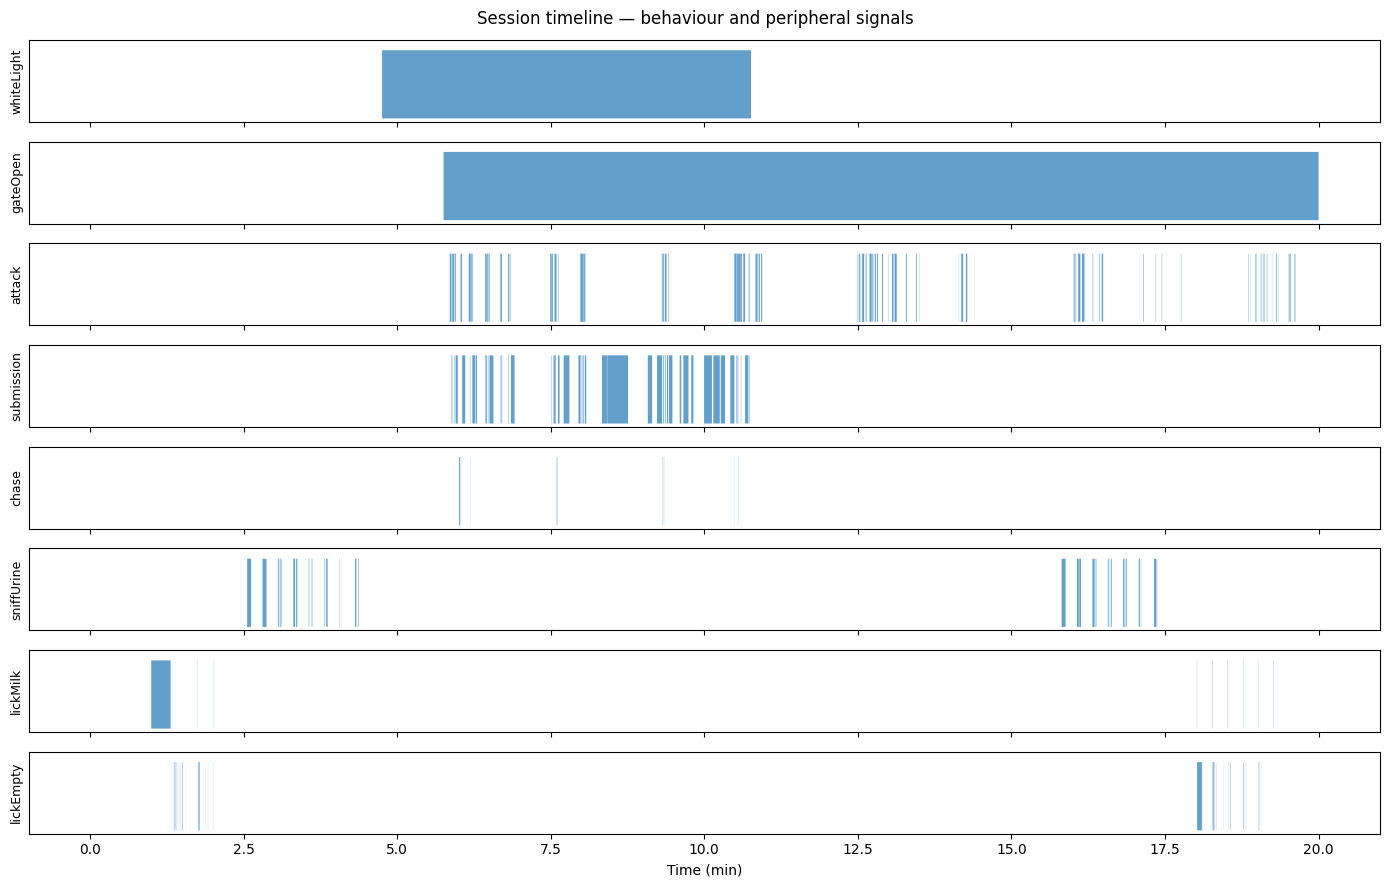

In [5]:
# Session timeline plot
overview_channels = [
    ("whiteLight", white_light),
    ("gateOpen",   gate_open),
    ("attack",     attack),
    ("submission", submission),
    ("chase",      chase),
    ("sniffUrine", sniff_urine),
    ("lickMilk",   lick_milk),
    ("lickEmpty",  lick_empty),
]

fig, axes = plt.subplots(len(overview_channels), 1, figsize=(14, 9), sharex=True)
for ax, (nm, mask) in zip(axes, overview_channels):
    ax.fill_between(t_min, mask.astype(int), step="mid", alpha=0.7)
    ax.set_ylabel(nm, fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks([])

axes[-1].set_xlabel("Time (min)")
fig.suptitle("Session timeline — behaviour and peripheral signals")
plt.tight_layout()
plt.show()

**Descriptive takeaways** (this section is descriptive only):
- The paradigm is strongly phase-structured.
- Submission exists only in WhiteAgg; sniff/milk/lick_empty are confined to Pre/Post.
- All later analyses must disentangle behaviour effects from phase/context effects and their interaction.

## 4. Helper functions — geometry, decoding, permutation tests, trajectories

In [6]:
# =============================================================================
# SECTION 4 · All helper functions  (combined from both notebooks)
# =============================================================================

# ─── geometry ────────────────────────────────────────────────────────────────

def build_state_matrix(FRz, mask):
    """Return (n_bins × n_neurons) matrix for bins where mask is True."""
    return FRz[:, np.asarray(mask).astype(bool)].T


def condition_pattern(FRz, mask):
    """Mean firing-rate z-score vector across masked bins."""
    mask = np.asarray(mask).astype(bool)
    if mask.sum() == 0:
        return np.zeros(FRz.shape[0])
    return FRz[:, mask].mean(axis=1)


def state_centroids(FRz, state_masks):
    return {k: condition_pattern(FRz, m) for k, m in state_masks.items()}


def pairwise_distance_tables(centroid_dict):
    """Euclidean distance matrix and cosine similarity matrix for a set of centroids."""
    keys = list(centroid_dict.keys())
    X    = np.stack([centroid_dict[k] for k in keys], axis=0)
    eu   = pd.DataFrame(cdist(X, X, metric="euclidean"), index=keys, columns=keys)
    coss = pd.DataFrame(1 - cdist(X, X, metric="cosine"),  index=keys, columns=keys)
    return eu, coss


def vector_alignment_table(vector_dict):
    """Cosine similarity and Euclidean distance between a set of difference vectors."""
    keys = list(vector_dict.keys())
    X    = np.stack([vector_dict[k] for k in keys], axis=0)
    coss = pd.DataFrame(1 - cdist(X, X, metric="cosine"),  index=keys, columns=keys)
    eu   = pd.DataFrame(cdist(X, X, metric="euclidean"), index=keys, columns=keys)
    return coss, eu


def pattern_rdm(patterns, metric="cosine"):
    """
    Full representational dissimilarity matrix (RDM) across all conditions.
    patterns : dict of {condition_name: pattern_vector}
    """
    keys = list(patterns.keys())
    X    = np.stack([patterns[k] for k in keys], axis=0)
    return pd.DataFrame(cdist(X, X, metric=metric), index=keys, columns=keys)


def all_condition_centroid_map(FRz, condition_masks, min_samples=50, n_components=3):
    """
    Project all condition centroids into a shared PCA space.
    Returns (fitted_pca, DataFrame of PC coordinates + n_bins per condition).
    """
    valid = {k: np.asarray(v).astype(bool)
             for k, v in condition_masks.items()
             if int(np.asarray(v).astype(bool).sum()) >= min_samples}
    names = list(valid.keys())
    X     = np.stack([FRz[:, valid[k]].mean(axis=1) for k in names], axis=0)
    pca   = PCA(n_components=min(n_components, X.shape[0], X.shape[1]), random_state=0)
    Xp    = pca.fit_transform(X)
    df    = pd.DataFrame(Xp, index=names,
                         columns=[f"PC{i+1}" for i in range(Xp.shape[1])])
    df["n_bins"] = [int(valid[k].sum()) for k in names]
    return pca, df


def top_loading_table(vec, top_k=15):
    """Table of neurons with largest absolute loadings along a given vector."""
    vec = np.asarray(vec)
    return pd.DataFrame({
        "neuron":       np.arange(len(vec)),
        "abs_loading":  np.abs(vec),
        "loading":      vec,
    }).sort_values("abs_loading", ascending=False).head(top_k)


# ─── decoding ────────────────────────────────────────────────────────────────

def _make_decoder():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=4000, class_weight="balanced", C=0.1),
    )


def within_phase_cv_binwise(X_pos, X_neg, n_splits=5, random_state=0):
    """
    Bin-level stratified k-fold CV.
    OPTIMISTIC: ignores temporal autocorrelation between adjacent bins.
    Use alongside grouped CV to bracket the true value.
    """
    X   = np.vstack([X_pos, X_neg])
    y   = np.concatenate([np.ones(len(X_pos)), np.zeros(len(X_neg))]).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    bas, cms = [], []
    for tr, te in skf.split(X, y):
        clf = _make_decoder().fit(X[tr], y[tr])
        bas.append(balanced_accuracy_score(y[te], clf.predict(X[te])))
        cms.append(confusion_matrix(y[te], clf.predict(X[te])))
    return {
        "balanced_accuracy_mean": float(np.mean(bas)),
        "balanced_accuracy_std":  float(np.std(bas, ddof=1)),
        "validation":             "binwise",
    }, np.sum(cms, axis=0)


def _chunk_mask(mask, chunk_len):
    """Assign contiguous time chunks of a mask to integer group IDs."""
    idx    = np.flatnonzero(mask)
    groups = np.full(len(mask), -1, dtype=int)
    for g, start in enumerate(range(0, len(idx), chunk_len)):
        groups[idx[start: start + chunk_len]] = g
    return groups


def within_phase_cv_grouped(FRz, mask_pos, mask_neg, neg_chunk_len=50, n_splits=5, random_state=0):
    """
    Grouped k-fold CV: time chunks (size=neg_chunk_len bins) as groups.
    CONSERVATIVE: reduces autocorrelation inflation.
    """
    mask_pos = np.asarray(mask_pos).astype(bool)
    mask_neg = np.asarray(mask_neg).astype(bool)

    X_pos    = build_state_matrix(FRz, mask_pos)
    X_neg    = build_state_matrix(FRz, mask_neg)
    grp_pos  = _chunk_mask(mask_pos, neg_chunk_len)[mask_pos]
    grp_neg  = _chunk_mask(mask_neg, neg_chunk_len)[mask_neg] + grp_pos.max() + 1

    X = np.vstack([X_pos, X_neg])
    y = np.concatenate([np.ones(len(X_pos)), np.zeros(len(X_neg))]).astype(int)
    g = np.concatenate([grp_pos, grp_neg])

    n_splits_used = min(n_splits, len(np.unique(g)))
    if n_splits_used < 2:
        return {"balanced_accuracy_mean": np.nan,
                "balanced_accuracy_std":  np.nan,
                "validation":             "grouped"}, None

    bas, cms = [], []
    for tr, te in GroupKFold(n_splits=n_splits_used).split(X, y, groups=g):
        clf = _make_decoder().fit(X[tr], y[tr])
        bas.append(balanced_accuracy_score(y[te], clf.predict(X[te])))
        cms.append(confusion_matrix(y[te], clf.predict(X[te])))
    return {
        "balanced_accuracy_mean": float(np.mean(bas)),
        "balanced_accuracy_std":  float(np.std(bas, ddof=1)),
        "validation":             "grouped",
    }, np.sum(cms, axis=0)


def explicit_cross_phase_decode(X_train_pos, X_train_neg, X_test_pos, X_test_neg):
    """
    Train on one phase, test on another.
    Direct measurement of cross-phase generalisation (no cross-val needed).
    """
    X_train = np.vstack([X_train_pos, X_train_neg])
    y_train = np.concatenate([np.ones(len(X_train_pos)),
                              np.zeros(len(X_train_neg))]).astype(int)
    X_test  = np.vstack([X_test_pos, X_test_neg])
    y_test  = np.concatenate([np.ones(len(X_test_pos)),
                              np.zeros(len(X_test_neg))]).astype(int)
    clf = _make_decoder().fit(X_train, y_train)
    return {
        "balanced_accuracy": float(balanced_accuracy_score(y_test, clf.predict(X_test))),
        "validation":        "cross_phase",
    }, confusion_matrix(y_test, clf.predict(X_test))


def multiclass_cv(state_dict, n_splits=5, random_state=0):
    """
    Balanced multiclass stratified k-fold CV.
    state_dict: {class_name: X_matrix (n_bins × n_neurons)}
    """
    rng    = np.random.default_rng(random_state)
    names  = list(state_dict.keys())
    counts = [len(v) for v in state_dict.values()]
    n_bal  = min(counts)
    if n_bal < n_splits:
        return None, None
    Xs, ys = [], []
    for i, (nm, X) in enumerate(state_dict.items()):
        idx = rng.choice(len(X), size=n_bal, replace=False)
        Xs.append(X[idx]); ys.extend([i] * n_bal)
    X_all = np.vstack(Xs); y_all = np.array(ys)
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    bas, cms = [], []
    for tr, te in skf.split(X_all, y_all):
        clf = _make_decoder().fit(X_all[tr], y_all[tr])
        bas.append(balanced_accuracy_score(y_all[te], clf.predict(X_all[te])))
        cms.append(confusion_matrix(y_all[te], clf.predict(X_all[te]),
                                   labels=list(range(len(names)))))
    return {
        "balanced_accuracy_mean": float(np.mean(bas)),
        "balanced_accuracy_std":  float(np.std(bas, ddof=1)),
        "n_classes":              len(names),
        "class_names":            names,
        "validation":             "multiclass_binwise",
    }, np.sum(cms, axis=0)
def multiclass_cv_grouped(mask_dict, FRz, chunk_len=50, n_splits=5, random_state=0):
    """
    Grouped multiclass k-fold CV — reduces autocorrelation inflation.
    mask_dict: {class_name: boolean mask over time}
    Each class is chunked into blocks of chunk_len bins; blocks are the CV groups.
    """
    rng   = np.random.default_rng(random_state)
    names = list(mask_dict.keys())

    # build per-class (X, group) pairs
    Xs, ys, gs = [], [], []
    group_offset = 0
    for i, (nm, mask) in enumerate(mask_dict.items()):
        idx = np.flatnonzero(mask)
        X   = FRz[:, idx].T                          # (n_bins, n_neurons)
        # assign chunk group IDs
        grp = np.full(len(idx), -1, dtype=int)
        for g, start in enumerate(range(0, len(idx), chunk_len)):
            grp[start: start + chunk_len] = g + group_offset
        group_offset = grp.max() + 1
        Xs.append(X); ys.extend([i] * len(X)); gs.extend(grp.tolist())

    X_all = np.vstack(Xs)
    y_all = np.array(ys)
    g_all = np.array(gs)

    n_splits_used = min(n_splits, len(np.unique(g_all)))
    if n_splits_used < 2:
        return None, None

    bas, cms = [], []
    for tr, te in GroupKFold(n_splits=n_splits_used).split(X_all, y_all, groups=g_all):
        clf = _make_decoder().fit(X_all[tr], y_all[tr])
        bas.append(balanced_accuracy_score(y_all[te], clf.predict(X_all[te])))
        cms.append(confusion_matrix(y_all[te], clf.predict(X_all[te]),
                                    labels=list(range(len(names)))))
    return {
        "balanced_accuracy_mean": float(np.mean(bas)),
        "balanced_accuracy_std":  float(np.std(bas, ddof=1)),
        "n_classes":              len(names),
        "class_names":            names,
        "validation":             "multiclass_grouped",
    }, np.sum(cms, axis=0)

def decoder_weight_table(clf, top_k=15):
    """Top-weighted neurons from a fitted LogisticRegression pipeline."""
    w = clf.named_steps["logisticregression"].coef_.ravel()
    return pd.DataFrame({
        "neuron":      np.arange(len(w)),
        "abs_weight":  np.abs(w),
        "weight":      w,
    }).sort_values("abs_weight", ascending=False).head(top_k)


# ─── permutation tests ────────────────────────────────────────────────────────

def circular_shift_mask_within_phase(event_mask, phase_mask, shift):
    """Circular-shift event_mask within the bins of phase_mask."""
    event_mask = np.asarray(event_mask).astype(bool)
    phase_mask = np.asarray(phase_mask).astype(bool)
    idx = np.flatnonzero(phase_mask)
    out = event_mask.copy()
    out[idx] = np.roll(event_mask[idx], shift)
    return out


def participation_ratio(X):
    """Effective dimensionality of a state matrix (n_bins × n_neurons)."""
    if X.shape[0] < 2:
        return float(X.shape[1])
    pca = PCA(); pca.fit(X)
    ev  = pca.explained_variance_; ev = ev[ev > 0]
    if ev.sum() == 0:
        return 1.0
    return float((ev.sum() ** 2) / np.sum(ev ** 2))


def occupancy_modulation_by_phase_fast(
    FRz, event_mask, phase_mask,
    n_perm=1000, alpha=0.05, min_effect=0.15, seed=0, block_size=50,
):
    """
    Per-neuron significance using BLOCK CIRCULAR-SHIFT permutation test.
    This is the correct approach for temporally autocorrelated data.

    Returns
    -------
    df      : per-neuron DataFrame with effect sizes and p-values
    summary : dict with n_up, n_down, n_significant_any
    """
    event_mask  = np.asarray(event_mask, dtype=bool)
    phase_mask  = np.asarray(phase_mask, dtype=bool)
    mask_event  = event_mask & phase_mask
    mask_non    = (~event_mask) & phase_mask
    if mask_event.sum() < 2 or mask_non.sum() < 2:
        return pd.DataFrame(), {"n_up": 0, "n_down": 0, "n_significant_any": 0}

    rng        = np.random.default_rng(seed)
    idx_phase  = np.flatnonzero(phase_mask)
    n_phase    = len(idx_phase)
    rows       = []

    for i in range(FRz.shape[0]):
        obs_diff = FRz[i, mask_event].mean() - FRz[i, mask_non].mean()
        perm_diffs = []
        for _ in range(n_perm):
            shift = int(rng.integers(block_size, max(n_phase - block_size, block_size + 1)))
            sh    = circular_shift_mask_within_phase(event_mask, phase_mask, shift)
            me    = sh & phase_mask
            mn    = (~sh) & phase_mask
            if me.sum() < 2 or mn.sum() < 2:
                perm_diffs.append(0.0); continue
            perm_diffs.append(FRz[i, me].mean() - FRz[i, mn].mean())

        perm_diffs = np.array(perm_diffs)
        p_two = 2 * min(
            (perm_diffs >= obs_diff).mean(),
            (perm_diffs <= obs_diff).mean(),
        )
        p_two = max(p_two, 1.0 / n_perm)
        var_e   = FRz[i, mask_event].var(ddof=1)
        var_n   = FRz[i, mask_non].var(ddof=1)
        pooled  = np.sqrt((var_e + var_n) / 2.0 + 1e-12)
        effect  = obs_diff / pooled
        rows.append({
            "neuron":          i,
            "mean_diff":       obs_diff,
            "effect_size_d":   effect,
            "p_value":         p_two,
            "responsive_up":   bool((obs_diff > 0) and (p_two < alpha) and (abs(effect) >= min_effect)),
            "responsive_down": bool((obs_diff < 0) and (p_two < alpha) and (abs(effect) >= min_effect)),
        })

    df = pd.DataFrame(rows)
    df["significant_any"] = df["responsive_up"] | df["responsive_down"]
    summary = {
        "n_up":              int(df["responsive_up"].sum()),
        "n_down":            int(df["responsive_down"].sum()),
        "n_significant_any": int(df["significant_any"].sum()),
    }
    return df, summary


def phase_shift_permutation_test(Xa, Xb, n_perm=500, rng=0):
    """
    PR-based permutation test: observed PR(Xa)-PR(Xb) vs label-shuffled null.
    """
    rng   = np.random.default_rng(rng)
    pr_a  = participation_ratio(Xa)
    pr_b  = participation_ratio(Xb)
    obs   = pr_a - pr_b
    X_all = np.vstack([Xa, Xb])
    y_all = np.concatenate([np.zeros(len(Xa)), np.ones(len(Xb))]).astype(int)
    null  = []
    for _ in range(n_perm):
        yp = rng.permutation(y_all)
        null.append(participation_ratio(X_all[yp == 0]) -
                    participation_ratio(X_all[yp == 1]))
    null = np.array(null)
    p    = (np.abs(null) >= np.abs(obs)).mean()
    return {"pr_a": pr_a, "pr_b": pr_b, "pr_diff_obs": obs, "p_perm": float(p)}


# ─── trajectory helpers ───────────────────────────────────────────────────────

def onsets_from_mask(mask):
    """Return time indices where mask transitions from 0 → 1."""
    diff = np.diff(np.concatenate([[0], np.asarray(mask).astype(int)]))
    return np.flatnonzero(diff == 1)


def filter_onsets_by_phase_and_window(onsets, phase_mask, nT, pre_bins, post_bins):
    return np.array([o for o in onsets
                     if pre_bins <= o < nT - post_bins and phase_mask[o]], dtype=int)


def filter_clean_pre_onsets(mask, onsets, pre_bins):
    """Keep only onsets with no event in the pre-window."""
    m = np.asarray(mask).astype(bool)
    return np.array([o for o in onsets
                     if m[max(0, o - pre_bins):o].sum() == 0], dtype=int)


def filter_clean_prepost_onsets(mask, onsets, pre_bins, post_bins):
    """Keep only onsets with no event in either pre- or post-window."""
    m = np.asarray(mask).astype(bool)
    return np.array([o for o in onsets
                     if m[max(0, o - pre_bins):o].sum() == 0
                     and m[o + 1: min(len(m), o + post_bins + 1)].sum() == 0], dtype=int)


def extract_event_windows(FRz, onsets, pre_bins, post_bins):
    """Return (n_events × n_time × n_neurons) tensor."""
    wins = [FRz[:, o - pre_bins: o + post_bins + 1].T
            for o in onsets.astype(int)]
    if not wins:
        return np.zeros((0, pre_bins + post_bins + 1, FRz.shape[0]))
    return np.stack(wins, axis=0)


def mean_sem(x, axis=0):
    x = np.asarray(x, dtype=float)
    m = np.nanmean(x, axis=axis)
    s = np.nanstd(x,  axis=axis, ddof=1) / np.sqrt(max(1, x.shape[axis]))
    return m, s


def latent_speed(traj_pca, dims=3, dt=1 / 50):
    """Frame-to-frame speed in latent PCA space."""
    X  = traj_pca[:, :, :dims]
    dX = np.diff(X, axis=1)
    return np.linalg.norm(dX, axis=2) / dt


def time_resolved_centroid_distance(traj_a, traj_b, metric="euclidean"):
    """
    Per-time-point distance between the mean trajectories of two conditions.
    traj_a, traj_b : (n_events × n_time × n_dims)
    """
    mean_a = traj_a.mean(axis=0)     # (n_time × n_dims)
    mean_b = traj_b.mean(axis=0)
    return np.array([
        cdist(mean_a[t: t + 1], mean_b[t: t + 1], metric=metric)[0, 0]
        for t in range(mean_a.shape[0])
    ])


def time_resolved_distance_from_pre(traj, pre_bins, metric="euclidean"):
    """
    Per-time-point distance of the mean trajectory from the pre-onset centroid.
    """
    pre_centroid = traj[:, :pre_bins, :].mean(axis=(0, 1), keepdims=True)
    mean_traj    = traj.mean(axis=0)
    return np.array([
        cdist(mean_traj[t: t + 1], pre_centroid.reshape(1, -1), metric=metric)[0, 0]
        for t in range(mean_traj.shape[0])
    ])


def compute_pre_post_displacement(traj, pre_bins, post_slice=(0, 50)):
    """
    Per-event displacement from pre-onset centroid to an early post-onset window.
    Returns (pre_centroids, post_centroids, delta_vectors, norms).
    """
    pre  = traj[:, :pre_bins, :].mean(axis=1)
    ps, pe = post_slice
    post = traj[:, pre_bins + ps: pre_bins + pe, :].mean(axis=1)
    delta = post - pre
    norm  = np.linalg.norm(delta, axis=1)
    return pre, post, delta, norm


# ─── rolling drift ────────────────────────────────────────────────────────────

def rolling_window_centroids(FRz, mask, win_bins, step_bins):
    mask = np.asarray(mask).astype(bool)
    idx  = np.flatnonzero(mask)
    if len(idx) < win_bins:
        return np.array([]), np.zeros((0, FRz.shape[0]))
    centers, vecs = [], []
    for start in range(0, len(idx) - win_bins + 1, step_bins):
        chunk = idx[start: start + win_bins]
        centers.append((chunk[0] + chunk[-1]) / 2.0)
        vecs.append(FRz[:, chunk].mean(axis=1))
    if not vecs:
        return np.array([]), np.zeros((0, FRz.shape[0]))
    return np.array(centers), np.stack(vecs, axis=0)


def dist_from_ref(vecs, ref):
    if len(vecs) == 0:
        return np.array([])
    return cdist(vecs, ref[None, :], metric="euclidean")[:, 0]


print("All helper functions loaded.")

All helper functions loaded.


## 5. Attack state geometry & decoding

**Question**: Is attack strongly separable within phase, and is the attack-related
modulation aligned across White and Dark conditions?

This section reports geometry, explicit numbers, binwise validation, AND grouped
validation — so that strong-looking separation is not presented as if it were
independent-trial generalisation.

In [7]:
# =============================================================================
# SECTION 5 · Attack state geometry
# =============================================================================

attack_states = {
    "WA": phase_masks["WhiteAgg"] & attack,
    "WN": phase_masks["WhiteAgg"] & (~attack),
    "DA": phase_masks["DarkAgg"]  & attack,
    "DN": phase_masks["DarkAgg"]  & (~attack),
}

attack_state_sizes = pd.DataFrame({
    "state":  list(attack_states.keys()),
    "n_bins": [int(v.sum()) for v in attack_states.values()],
})
display(attack_state_sizes)

attack_centroids = state_centroids(FRz, attack_states)
attack_eu, attack_cos = pairwise_distance_tables(attack_centroids)
print("Euclidean centroid distances:");  display(attack_eu.round(3))
print("Cosine similarity (centroids):"); display(attack_cos.round(3))

,state,n_bins
0,WA,1856
1,WN,13144
2,DA,1175
3,DN,13825


Euclidean centroid distances:


,WA,WN,DA,DN
WA,0.0000,2.2940,5.5990,5.3430
WN,2.2940,0.0000,5.3590,4.7590
DA,5.5990,5.3590,0.0000,2.4080
DN,5.3430,4.7590,2.4080,0.0000


Cosine similarity (centroids):


,WA,WN,DA,DN
WA,1.0000,0.8480,0.4260,0.3300
WN,0.8480,1.0000,0.4600,0.4410
DA,0.4260,0.4600,1.0000,0.9150
DN,0.3300,0.4410,0.9150,1.0000


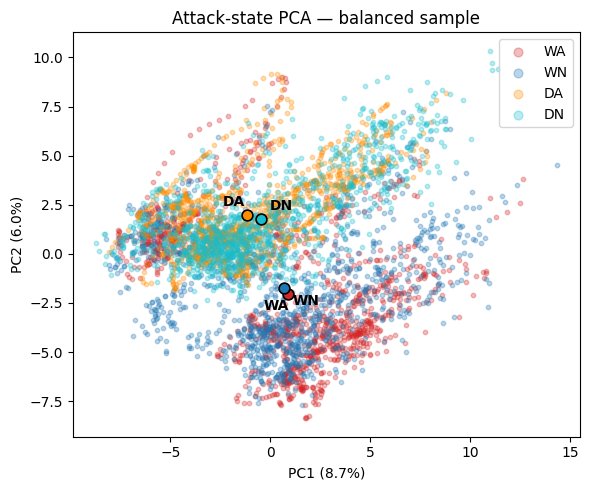

Explained variance ratio PC1-2: [0.087  0.0595]


In [8]:
# PCA 2-D scatter (balanced sample)
rng = np.random.default_rng(0)
sample_n = min([int(m.sum()) for m in attack_states.values()] + [1500])
Xs_att, lbl_att = [], []
for nm, mask in attack_states.items():
    idx  = np.flatnonzero(mask)
    pick = rng.choice(idx, size=sample_n, replace=False)
    Xs_att.append(FRz[:, pick].T); lbl_att.extend([nm] * sample_n)
X_att_vis = np.vstack(Xs_att); lbl_att = np.array(lbl_att)

pca_attack = PCA(n_components=2, random_state=0)
Z_att      = pca_attack.fit_transform(X_att_vis)

att_cols = {"WA": "tab:red", "WN": "tab:blue", "DA": "darkorange", "DN": "tab:cyan"}

# 手动控制每个标注的偏移方向，避免重叠
label_offsets = {"WA": (-18, -12), "WN": (6, -12), "DA": (-18, 6), "DN": (6, 6)}

fig, ax = plt.subplots(figsize=(6, 5))

for nm in attack_states:
    sel = lbl_att == nm
    ax.scatter(Z_att[sel, 0], Z_att[sel, 1],
               s=10, alpha=0.3, label=nm, c=att_cols[nm])

for nm in attack_states:
    sel = lbl_att == nm
    cx, cy = Z_att[sel, 0].mean(), Z_att[sel, 1].mean()
    ax.scatter(cx, cy, s=60, c=att_cols[nm],
               edgecolors="black", linewidths=1.2, zorder=5)
    ax.annotate(nm, (cx, cy), textcoords="offset points",
                xytext=label_offsets[nm], fontsize=10, fontweight="bold")

ax.set_xlabel(f"PC1 ({pca_attack.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_attack.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Attack-state PCA — balanced sample")
ax.legend(markerscale=2)
plt.tight_layout(); plt.show()
print("Explained variance ratio PC1-2:", np.round(pca_attack.explained_variance_ratio_, 4))

In [9]:
# Within-phase decoding: BINWISE  (optimistic)  +  GROUPED  (conservative)
X_WA = build_state_matrix(FRz, attack_states["WA"])
X_WN = build_state_matrix(FRz, attack_states["WN"])
X_DA = build_state_matrix(FRz, attack_states["DA"])
X_DN = build_state_matrix(FRz, attack_states["DN"])

bw_white, _ = within_phase_cv_binwise(X_WA, X_WN)
gp_white, _ = within_phase_cv_grouped(FRz, attack_states["WA"], attack_states["WN"], neg_chunk_len=50)
bw_dark,  _ = within_phase_cv_binwise(X_DA, X_DN)
gp_dark,  _ = within_phase_cv_grouped(FRz, attack_states["DA"], attack_states["DN"],  neg_chunk_len=50)

attack_decode_df = pd.DataFrame([bw_white, gp_white, bw_dark, gp_dark], index=[
    "White attack vs nonattack (binwise)",
    "White attack vs nonattack (grouped)",
    "Dark  attack vs nonattack (binwise)",
    "Dark  attack vs nonattack (grouped)",
])
display(attack_decode_df.round(4))

,balanced_accuracy_mean,balanced_accuracy_std,validation
White attack vs nonattack (binwise),0.9314,0.0077,binwise
White attack vs nonattack (grouped),0.7569,0.0584,grouped
Dark attack vs nonattack (binwise),0.9409,0.0078,binwise
Dark attack vs nonattack (grouped),0.6624,0.0505,grouped


In [10]:
# White-vs-Dark matched-state decoding  →  quantifies phase/context separability
wa_vs_da, _ = explicit_cross_phase_decode(X_WA, X_DA, X_WA, X_DA)
wn_vs_dn, _ = explicit_cross_phase_decode(X_WN, X_DN, X_WN, X_DN)
wd_df = pd.DataFrame([wa_vs_da, wn_vs_dn], index=[
    "WA vs DA — phase/context separability (attack bins)",
    "WN vs DN — phase/context separability (nonattack bins)",
])
display(wd_df.round(4))

,balanced_accuracy,validation
WA vs DA — phase/context separability (attack bins),1.0000,cross_phase
WN vs DN — phase/context separability (nonattack bins),0.9998,cross_phase


In [11]:
# Attack modulation vector alignment
delta_attack_white = attack_centroids["WA"] - attack_centroids["WN"]
delta_attack_dark  = attack_centroids["DA"] - attack_centroids["DN"]

atk_vec_cos, atk_vec_eu = vector_alignment_table({
    "Δ_attack_White": delta_attack_white,
    "Δ_attack_Dark":  delta_attack_dark,
})
print("Attack modulation vector cosine similarity:"); display(atk_vec_cos.round(3))
print("Attack modulation vector Euclidean distance:"); display(atk_vec_eu.round(3))

attack_alignment_summary = pd.DataFrame([{
    "cosine_similarity":  float(atk_vec_cos.loc["Δ_attack_White", "Δ_attack_Dark"]),
    "euclidean_distance": float(atk_vec_eu.loc["Δ_attack_White", "Δ_attack_Dark"]),
    "White_norm": float(np.linalg.norm(delta_attack_white)),
    "Dark_norm":  float(np.linalg.norm(delta_attack_dark)),
}])
display(attack_alignment_summary.round(4))

Attack modulation vector cosine similarity:


,Δ_attack_White,Δ_attack_Dark
Δ_attack_White,1.0000,0.2970
Δ_attack_Dark,0.2970,1.0000


Attack modulation vector Euclidean distance:


,Δ_attack_White,Δ_attack_Dark
Δ_attack_White,0.0000,2.7900
Δ_attack_Dark,2.7900,0.0000


,cosine_similarity,euclidean_distance,White_norm,Dark_norm
0,0.2967,2.7901,2.2943,2.4081


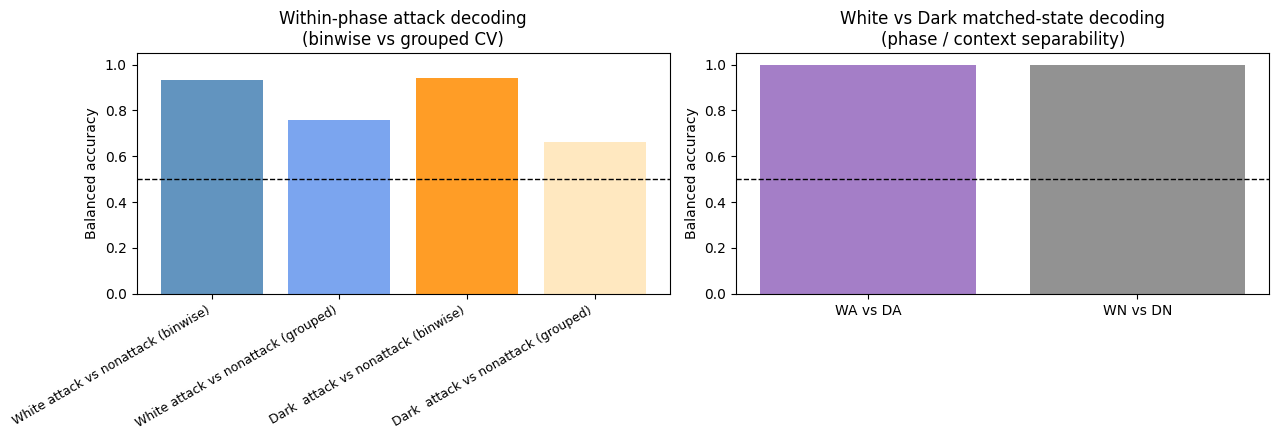

In [12]:
# Summary figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

vals_w = attack_decode_df["balanced_accuracy_mean"].values
bar_colors = ["steelblue", "cornflowerblue", "darkorange", "moccasin"]
axes[0].bar(np.arange(4), vals_w, color=bar_colors, alpha=0.85)
axes[0].axhline(0.5, color="k", ls="--", lw=1)
axes[0].set_xticks(np.arange(4))
axes[0].set_xticklabels(attack_decode_df.index, rotation=30, ha="right", fontsize=9)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Balanced accuracy")
axes[0].set_title("Within-phase attack decoding\n(binwise vs grouped CV)")

vals2 = [wa_vs_da["balanced_accuracy"], wn_vs_dn["balanced_accuracy"]]
axes[1].bar([0, 1], vals2, color=["tab:purple", "tab:gray"], alpha=0.85)
axes[1].axhline(0.5, color="k", ls="--", lw=1)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["WA vs DA", "WN vs DN"])
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("Balanced accuracy")
axes[1].set_title("White vs Dark matched-state decoding\n(phase / context separability)")

plt.tight_layout(); plt.show()

**Interpretation — Section 5**

*Supported*
- Attack is strongly separable within both White and Dark, even under grouped CV.
- White vs Dark is strongly separable even when matching attack/non-attack state → strong phase/context encoding beyond behaviour alone.
- White and Dark attack modulation vectors are only *partly* aligned → context-dependent representation, not one invariant code.

*Not supported*
- A claim that grouped CV provides unbiased trial-generalisation estimates.
- Any mechanistic circuit claim from linear separability alone.

## 6. Attack trajectories — clustered episode dynamics

**Framing**: the vast majority of attack onsets occur inside dense clusters.
Trajectories should therefore be interpreted as onset-referenced population dynamics
within clustered aggressive episodes — NOT as isolated single-event impulse responses.

In [13]:
# =============================================================================
# SECTION 6 · Attack trajectories
# =============================================================================

pre_sec   = 2.0;  post_sec  = 4.0
pre_bins  = int(pre_sec  * fs)
post_bins = int(post_sec * fs)
time_event = np.arange(-pre_bins, post_bins + 1) / fs

all_onsets  = onsets_from_mask(attack)
white_onset = filter_onsets_by_phase_and_window(
    all_onsets, phase_masks["WhiteAgg"], n_timebins, pre_bins, post_bins)
dark_onset  = filter_onsets_by_phase_and_window(
    all_onsets, phase_masks["DarkAgg"],  n_timebins, pre_bins, post_bins)

white_clean_pre     = filter_clean_pre_onsets(attack, white_onset, pre_bins)
dark_clean_pre      = filter_clean_pre_onsets(attack, dark_onset,  pre_bins)
white_clean_prepost = filter_clean_prepost_onsets(attack, white_onset, pre_bins, post_bins)
dark_clean_prepost  = filter_clean_prepost_onsets(attack, dark_onset,  pre_bins, post_bins)

event_clean_df = pd.DataFrame([
    {"condition": "White", "all_onsets": len(white_onset),
     "clean_pre": len(white_clean_pre), "clean_pre_post": len(white_clean_prepost)},
    {"condition": "Dark",  "all_onsets": len(dark_onset),
     "clean_pre": len(dark_clean_pre),  "clean_pre_post": len(dark_clean_prepost)},
])
display(event_clean_df)
print("\n⚠  Most onsets occur inside clustered bouts — "
      "trajectories reflect episode dynamics, not isolated transients.")

,condition,all_onsets,clean_pre,clean_pre_post
0,White,38,11,0
1,Dark,33,12,0



⚠  Most onsets occur inside clustered bouts — trajectories reflect episode dynamics, not isolated transients.


In [14]:
# Extract windows & fit event PCA
traj_white = extract_event_windows(FRz, white_onset, pre_bins, post_bins)
traj_dark  = extract_event_windows(FRz, dark_onset,  pre_bins, post_bins)

flat_events = np.concatenate([
    traj_white.reshape(-1, n_neurons),
    traj_dark.reshape(-1,  n_neurons),
], axis=0)
pca_evt = PCA(n_components=5, random_state=0)
pca_evt.fit(flat_events)
print("Event PCA explained variance ratio (PC1-5):",
      np.round(pca_evt.explained_variance_ratio_, 4))

traj_white_pca = (pca_evt.transform(traj_white.reshape(-1, n_neurons))
                 .reshape(len(traj_white), -1, 5))
traj_dark_pca  = (pca_evt.transform(traj_dark.reshape(-1,  n_neurons))
                 .reshape(len(traj_dark),  -1, 5))

mw = traj_white_pca.mean(axis=0)   # (n_time × 5)
md = traj_dark_pca.mean(axis=0)

Event PCA explained variance ratio (PC1-5): [0.0955 0.066  0.0442 0.0287 0.0228]


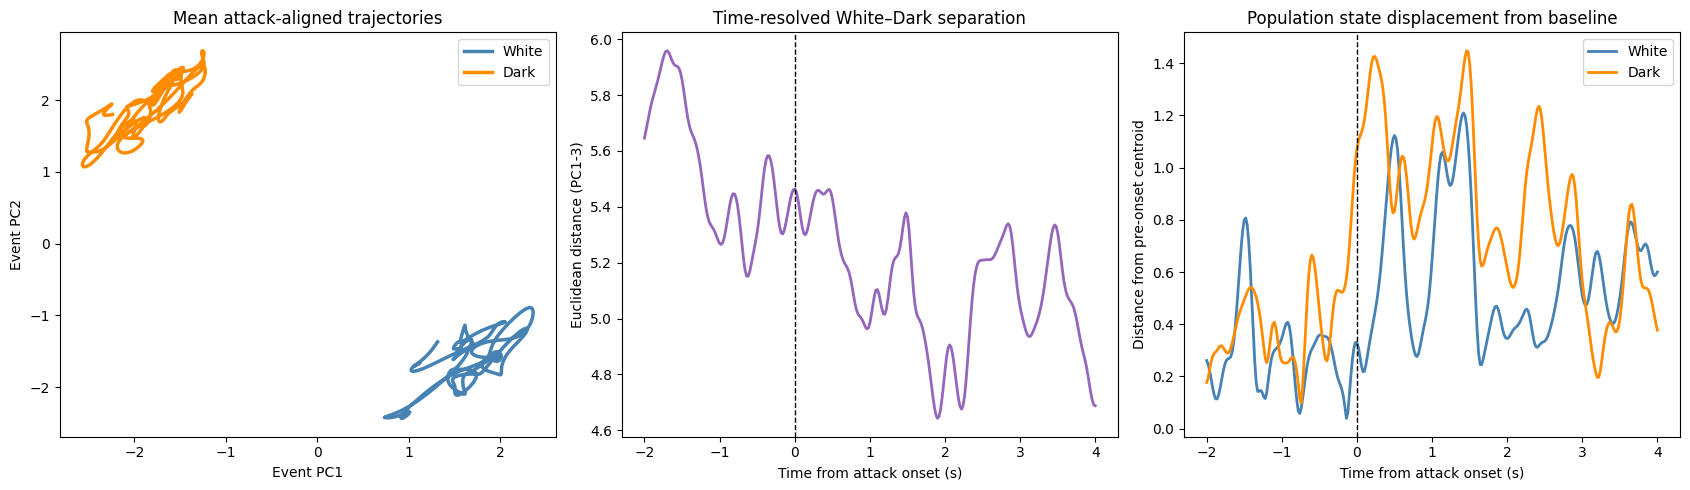

In [15]:
# Trajectory figures (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: mean trajectory in PC1–PC2
axes[0].plot(mw[:, 0], mw[:, 1], lw=2.5, label="White", color="steelblue")
axes[0].plot(md[:, 0], md[:, 1], lw=2.5, label="Dark",  color="darkorange")
axes[0].scatter(mw[pre_bins, 0], mw[pre_bins, 1], s=70, zorder=5, color="steelblue")
axes[0].scatter(md[pre_bins, 0], md[pre_bins, 1], s=70, zorder=5, color="darkorange")
axes[0].set_xlabel("Event PC1"); axes[0].set_ylabel("Event PC2")
axes[0].set_title("Mean attack-aligned trajectories")
axes[0].legend()

# Panel 2: time-resolved White–Dark distance (PC1-3)
wd_dist = time_resolved_centroid_distance(
    traj_white_pca[:, :, :3], traj_dark_pca[:, :, :3])
axes[1].plot(time_event, wd_dist, lw=2, color="tab:purple")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Time from attack onset (s)")
axes[1].set_ylabel("Euclidean distance (PC1-3)")
axes[1].set_title("Time-resolved White–Dark separation")

# Panel 3: distance from pre-onset centroid
d_from_pre_w = time_resolved_distance_from_pre(traj_white_pca[:, :, :3], pre_bins)
d_from_pre_d = time_resolved_distance_from_pre(traj_dark_pca[:, :, :3],  pre_bins)
axes[2].plot(time_event, d_from_pre_w, lw=2, label="White", color="steelblue")
axes[2].plot(time_event, d_from_pre_d, lw=2, label="Dark",  color="darkorange")
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].set_xlabel("Time from attack onset (s)")
axes[2].set_ylabel("Distance from pre-onset centroid")
axes[2].set_title("Population state displacement from baseline")
axes[2].legend()

plt.tight_layout(); plt.show()

Early-window displacement (0–0.5 s post onset):


,phase,n_events,mean_0_0.5s_disp,std
0,White,38,2.9644,1.7983
1,Dark,33,3.2482,2.3266


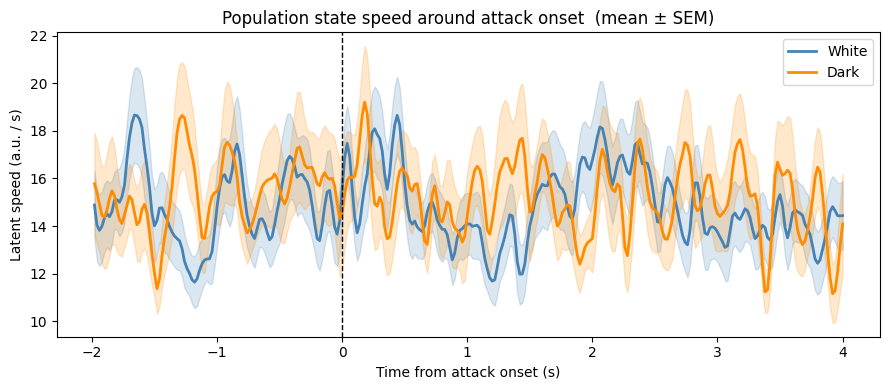

In [16]:
# Latent speed + early displacement table
speed_white = latent_speed(traj_white_pca, dims=3, dt=dt)
speed_dark  = latent_speed(traj_dark_pca,  dims=3, dt=dt)
mw_sp, sem_w_sp = mean_sem(speed_white, axis=0)
md_sp, sem_d_sp = mean_sem(speed_dark,  axis=0)
time_speed = time_event[1:]

_, _, _, disp_w = compute_pre_post_displacement(
    traj_white_pca[:, :, :3], pre_bins, post_slice=(0, int(0.5 * fs)))
_, _, _, disp_d = compute_pre_post_displacement(
    traj_dark_pca[:, :, :3],  pre_bins, post_slice=(0, int(0.5 * fs)))

early_disp_df = pd.DataFrame([
    {"phase": "White", "n_events": len(disp_w),
     "mean_0_0.5s_disp": disp_w.mean(), "std": disp_w.std(ddof=1)},
    {"phase": "Dark",  "n_events": len(disp_d),
     "mean_0_0.5s_disp": disp_d.mean(), "std": disp_d.std(ddof=1)},
])
print("Early-window displacement (0–0.5 s post onset):")
display(early_disp_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_speed, mw_sp, lw=2, label="White", color="steelblue")
ax.fill_between(time_speed, mw_sp - sem_w_sp, mw_sp + sem_w_sp,
                alpha=0.2, color="steelblue")
ax.plot(time_speed, md_sp, lw=2, label="Dark",  color="darkorange")
ax.fill_between(time_speed, md_sp - sem_d_sp, md_sp + sem_d_sp,
                alpha=0.2, color="darkorange")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Time from attack onset (s)")
ax.set_ylabel("Latent speed (a.u. / s)")
ax.set_title("Population state speed around attack onset  (mean ± SEM)")
ax.legend(); plt.tight_layout(); plt.show()

**Interpretation — Section 6**

- Attack episodes drive clear population-state motion (speed peak at onset).
- White and Dark episode trajectories occupy different regions of the event-defined PCA space.
- 0–0.5 s displacement table gives concrete numbers; trajectory plots give the picture.
- **Key caveat**: nearly all onsets are clustered (event cleanliness table). Do not interpret as isolated impulse responses.

## 7. Submission as a distinct White-phase social state

All comparisons stay within WhiteAgg to avoid the strongest phase confound.

**Question**: Is submission merely a weaker or opposite-sign version of attack,
or does it occupy a genuinely distinct position in White-phase population space?

In [17]:
# =============================================================================
# SECTION 7 · Submission geometry, decoding, and per-neuron modulation
# =============================================================================

white_attack_only     = phase_masks["WhiteAgg"] & attack     & (~submission)
white_submission_only = phase_masks["WhiteAgg"] & submission & (~attack)
white_baseline_social = phase_masks["WhiteAgg"] & (~attack)  & (~submission)

social_state_sizes = pd.DataFrame([
    {"state": "White baseline",         "n_bins": int(white_baseline_social.sum())},
    {"state": "White attack only",      "n_bins": int(white_attack_only.sum())},
    {"state": "White submission only",  "n_bins": int(white_submission_only.sum())},
])
display(social_state_sizes)

social_centroids_dict = state_centroids(FRz, {
    "W_baseline":    white_baseline_social,
    "W_attack_only": white_attack_only,
    "W_sub_only":    white_submission_only,
})
soc_eu, soc_cos = pairwise_distance_tables(social_centroids_dict)
print("Euclidean centroid distances:"); display(soc_eu.round(3))
print("Cosine similarity:");           display(soc_cos.round(3))

,state,n_bins
0,White baseline,8126
1,White attack only,1313
2,White submission only,5018


Euclidean centroid distances:


,W_baseline,W_attack_only,W_sub_only
W_baseline,0.0000,2.5460,1.9660
W_attack_only,2.5460,0.0000,2.7310
W_sub_only,1.9660,2.7310,0.0000


Cosine similarity:


,W_baseline,W_attack_only,W_sub_only
W_baseline,1.0000,0.8200,0.8910
W_attack_only,0.8200,1.0000,0.8050
W_sub_only,0.8910,0.8050,1.0000


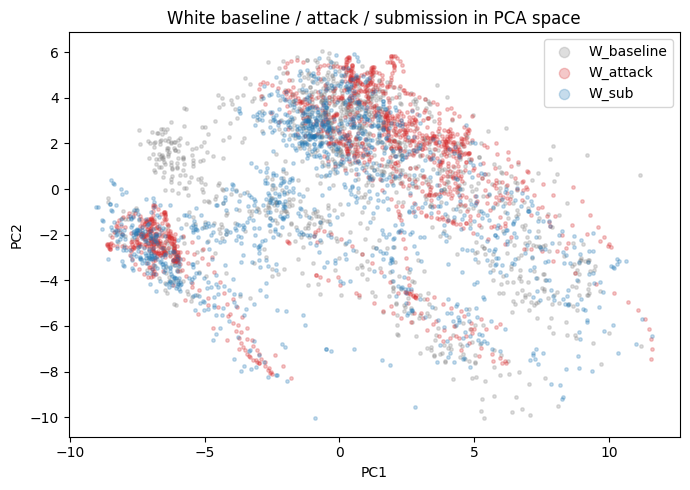

Explained variance ratio PC1-2: [0.1057 0.0602]


In [18]:
# PCA 2-D scatter
rng2 = np.random.default_rng(1)
sn_soc = min(int(white_baseline_social.sum()), int(white_attack_only.sum()),
             int(white_submission_only.sum()), 1300)
Xs_soc, ys_soc = [], []
soc_label_map = [("W_baseline", white_baseline_social),
                 ("W_attack",   white_attack_only),
                 ("W_sub",      white_submission_only)]
for nm, mask in soc_label_map:
    idx  = np.flatnonzero(mask)
    pick = rng2.choice(idx, size=sn_soc, replace=False)
    Xs_soc.append(FRz[:, pick].T); ys_soc.extend([nm] * sn_soc)
Xs_soc = np.vstack(Xs_soc); ys_soc = np.array(ys_soc)

pca_soc = PCA(n_components=2, random_state=0)
Zs_soc  = pca_soc.fit_transform(Xs_soc)

fig, ax = plt.subplots(figsize=(7, 5))
soc_cols = {"W_baseline": "tab:gray", "W_attack": "tab:red", "W_sub": "tab:blue"}
for nm in ["W_baseline", "W_attack", "W_sub"]:
    sel = ys_soc == nm
    ax.scatter(Zs_soc[sel, 0], Zs_soc[sel, 1],
               s=6, alpha=0.25, label=nm, c=soc_cols[nm])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("White baseline / attack / submission in PCA space")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()
print("Explained variance ratio PC1-2:", np.round(pca_soc.explained_variance_ratio_, 4))

In [19]:
# Attack vs submission decoding: binwise + grouped
X_att_soc = build_state_matrix(FRz, white_attack_only)
X_sub_soc  = build_state_matrix(FRz, white_submission_only)

bw_as, _ = within_phase_cv_binwise(X_att_soc, X_sub_soc)
gp_as, _ = within_phase_cv_grouped(FRz, white_attack_only, white_submission_only,
                                    neg_chunk_len=25)
atk_sub_df = pd.DataFrame([bw_as, gp_as], index=[
    "Attack vs submission (binwise)",
    "Attack vs submission (grouped)",
])
display(atk_sub_df.round(4))

,balanced_accuracy_mean,balanced_accuracy_std,validation
Attack vs submission (binwise),0.9593,0.0033,binwise
Attack vs submission (grouped),0.7991,0.0337,grouped


In [20]:
# Per-neuron significance — block circular-shift permutation (correct for autocorrelation)
# NOTE: n_perm=1000 is sufficient for p-value estimation; increase to 2000 for publication.
print("Running per-neuron permutation test: attack vs White baseline ...")
occ_atk_df, occ_atk_summary = occupancy_modulation_by_phase_fast(
    FRz, white_attack_only, phase_masks["WhiteAgg"],
    n_perm=1000, alpha=0.05, min_effect=0.15, seed=0)
print("Running per-neuron permutation test: submission vs White baseline ...")
occ_sub_df, occ_sub_summary = occupancy_modulation_by_phase_fast(
    FRz, white_submission_only, phase_masks["WhiteAgg"],
    n_perm=1000, alpha=0.05, min_effect=0.15, seed=1)

neuron_occ_df = pd.DataFrame([
    {"comparison": "attack vs White baseline",     **occ_atk_summary},
    {"comparison": "submission vs White baseline", **occ_sub_summary},
])
display(neuron_occ_df)

# Overlap between attack-up and submission-up neurons
if len(occ_atk_df) > 0 and len(occ_sub_df) > 0:
    atk_up = set(occ_atk_df.loc[occ_atk_df["responsive_up"],   "neuron"])
    sub_up = set(occ_sub_df.loc[occ_sub_df["responsive_up"],    "neuron"])
    atk_dn = set(occ_atk_df.loc[occ_atk_df["responsive_down"],  "neuron"])
    sub_dn = set(occ_sub_df.loc[occ_sub_df["responsive_down"],  "neuron"])
    print(f"\nNeurons up for attack AND up for submission :  {len(atk_up & sub_up)}")
    print(f"Neurons up for attack AND down for submission: {len(atk_up & sub_dn)}")

Running per-neuron permutation test: attack vs White baseline ...
Running per-neuron permutation test: submission vs White baseline ...


,comparison,n_up,n_down,n_significant_any
0,attack vs White baseline,4,5,9
1,submission vs White baseline,5,7,12



Neurons up for attack AND up for submission :  0
Neurons up for attack AND down for submission: 1


In [21]:
# Modulation vector alignment (attack vs sub, both relative to White baseline)
delta_atk_vs_base = (social_centroids_dict["W_attack_only"]
                     - social_centroids_dict["W_baseline"])
delta_sub_vs_base = (social_centroids_dict["W_sub_only"]
                     - social_centroids_dict["W_baseline"])

sub_vec_cos, sub_vec_eu = vector_alignment_table({
    "Δ_attack_vs_baseline":     delta_atk_vs_base,
    "Δ_submission_vs_baseline": delta_sub_vs_base,
})
print("Modulation vector cosine similarity:"); display(sub_vec_cos.round(3))

sub_alignment_summary = pd.DataFrame([{
    "cosine_similarity":  float(sub_vec_cos.loc[
        "Δ_attack_vs_baseline", "Δ_submission_vs_baseline"]),
    "euclidean_distance": float(sub_vec_eu.loc[
        "Δ_attack_vs_baseline", "Δ_submission_vs_baseline"]),
    "attack_norm":     float(np.linalg.norm(delta_atk_vs_base)),
    "submission_norm": float(np.linalg.norm(delta_sub_vs_base)),
}])
display(sub_alignment_summary.round(4))

Modulation vector cosine similarity:


,Δ_attack_vs_baseline,Δ_submission_vs_baseline
Δ_attack_vs_baseline,1.0000,0.2890
Δ_submission_vs_baseline,0.2890,1.0000


,cosine_similarity,euclidean_distance,attack_norm,submission_norm
0,0.2885,2.7313,2.5463,1.9658


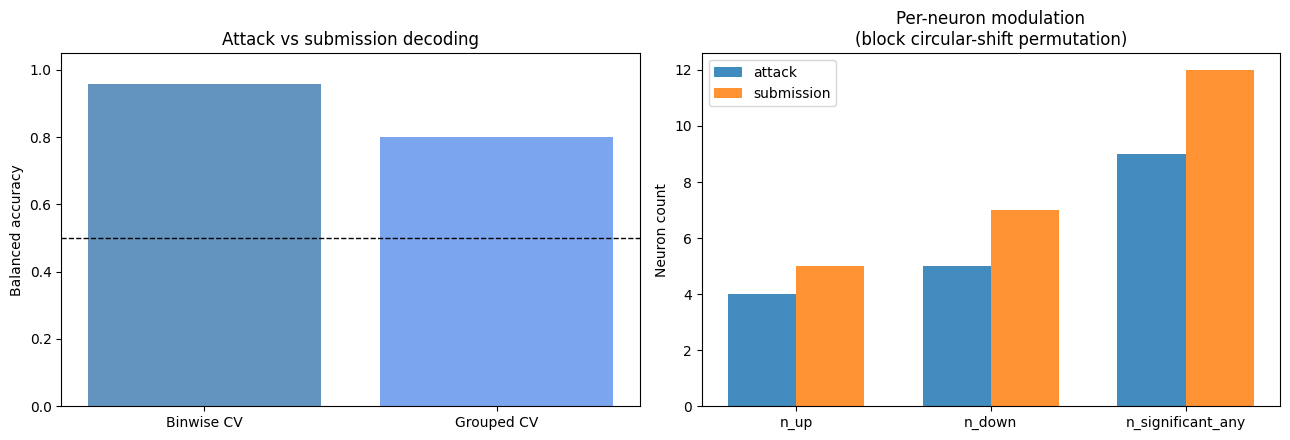

In [22]:
# Summary figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

vals_as = atk_sub_df["balanced_accuracy_mean"].values
axes[0].bar([0, 1], vals_as, color=["steelblue", "cornflowerblue"], alpha=0.85)
axes[0].axhline(0.5, color="k", ls="--", lw=1)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Binwise CV", "Grouped CV"])
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Balanced accuracy")
axes[0].set_title("Attack vs submission decoding")

cats = ["n_up", "n_down", "n_significant_any"]
x = np.arange(len(cats)); w = 0.35
axes[1].bar(x - w/2, [occ_atk_summary[c] for c in cats],
            width=w, label="attack", alpha=0.85)
axes[1].bar(x + w/2, [occ_sub_summary[c] for c in cats],
            width=w, label="submission", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(cats)
axes[1].set_ylabel("Neuron count")
axes[1].set_title("Per-neuron modulation\n(block circular-shift permutation)")
axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretation — Section 7**

*Supported*
- White baseline, attack, and submission are clearly separated at the population level.
- Attack vs submission decoding holds under grouped CV, not only bin-level.
- Relative to the same White baseline, attack and submission modulation vectors are only weakly aligned → distinct population states, not a continuum or an opposite-sign pattern.
- Per-neuron permutation (block circular-shift) correctly accounts for temporal autocorrelation.

*Not supported*
- A claim that attack and submission arise from entirely non-overlapping cell populations (circuit-level claim requires further evidence).
- Per-neuron tables are descriptive summaries, not cell typing.

## 8. Left / right visual-field decomposition

**Purpose**: check whether White-phase attack/submission structure is reducible
to the observer's left vs right visual field — one of the main confounds for
spatial coding in this paradigm.

In [23]:
# =============================================================================
# SECTION 8 · Left / right decomposition
# =============================================================================

white_atk_left  = phase_masks["WhiteAgg"] & attack_left      & (~attack_right)
white_atk_right = phase_masks["WhiteAgg"] & attack_right     & (~attack_left)
white_sub_left  = phase_masks["WhiteAgg"] & submission_left  & (~submission_right)
white_sub_right = phase_masks["WhiteAgg"] & submission_right & (~submission_left)

lr_sizes = pd.DataFrame([
    {"state": "white_attack_left",   "n_bins": int(white_atk_left.sum())},
    {"state": "white_attack_right",  "n_bins": int(white_atk_right.sum())},
    {"state": "white_sub_left",      "n_bins": int(white_sub_left.sum())},
    {"state": "white_sub_right",     "n_bins": int(white_sub_right.sum())},
])
display(lr_sizes)

lr_centroids_dict = state_centroids(FRz, {
    "attack_left":      white_atk_left,
    "attack_right":     white_atk_right,
    "submission_left":  white_sub_left,
    "submission_right": white_sub_right,
})
lr_eu, lr_cos = pairwise_distance_tables(lr_centroids_dict)
print("L/R centroid Euclidean distances:");  display(lr_eu.round(3))
print("L/R centroid cosine similarities:"); display(lr_cos.round(3))

,state,n_bins
0,white_attack_left,1349
1,white_attack_right,507
2,white_sub_left,4967
3,white_sub_right,594


L/R centroid Euclidean distances:


,attack_left,attack_right,submission_left,submission_right
attack_left,0.0000,2.6150,2.7780,3.1770
attack_right,2.6150,0.0000,3.2670,3.0690
submission_left,2.7780,3.2670,0.0000,4.2410
submission_right,3.1770,3.0690,4.2410,0.0000


L/R centroid cosine similarities:


,attack_left,attack_right,submission_left,submission_right
attack_left,1.0000,0.8450,0.7890,0.8300
attack_right,0.8450,1.0000,0.7530,0.8390
submission_left,0.7890,0.7530,1.0000,0.6660
submission_right,0.8300,0.8390,0.6660,1.0000


In [24]:
lr_rows = []
for label, mask_a, mask_b in [
    ("attack_left vs attack_right",        white_atk_left,  white_atk_right),
    ("submission_left vs submission_right", white_sub_left,  white_sub_right),
]:
    if mask_a.sum() > 20 and mask_b.sum() > 20:
        Xa = build_state_matrix(FRz, mask_a)
        Xb = build_state_matrix(FRz, mask_b)
        r_bw, _ = within_phase_cv_binwise(Xa, Xb)
        r_gp, _ = within_phase_cv_grouped(FRz, mask_a, mask_b, neg_chunk_len=25)
        lr_rows.append({"comparison": label + " (binwise)", **r_bw})
        lr_rows.append({"comparison": label + " (grouped)", **r_gp})
    else:
        print(f"  Skipping '{label}': insufficient bins in one or both sides.")

lr_decoder_df = pd.DataFrame(lr_rows)
if len(lr_decoder_df):
    display(lr_decoder_df.round(4))

,comparison,balanced_accuracy_mean,balanced_accuracy_std,validation
0,attack_left vs attack_right (binwise),0.9960,0.0035,binwise
1,attack_left vs attack_right (grouped),0.7173,0.0819,grouped
2,submission_left vs submission_right (binwise),0.9971,0.0022,binwise
3,submission_left vs submission_right (grouped),0.8306,0.0512,grouped


**Interpretation — Section 8**

- **If L/R separation is substantial** → some White-phase social structure may include a visual-field component; earlier attack/submission PCA separation is partially spatial.
- **If L/R separation is weak** → earlier White-phase distinctions are not reducible to visual-field position alone; they likely reflect social content.
- This is a **diagnostic check**, not a definitive resolution.
  Including this section makes the analysis more scientifically careful regardless of the outcome.

## 9. Pre → Post remapping of observer-side states

**Question**: Is the Pre → Post change a simple global baseline drift,
or does cue-related coding itself change between the two observer periods?

In [25]:
# =============================================================================
# SECTION 9 · Pre → Post remapping
# =============================================================================

pre_baseline_mask  = phase_masks["Pre"]  & (~sniff_urine) & (~lick_milk) & (~lick_empty)
pre_sniff_mask     = phase_masks["Pre"]  & sniff_urine    & (~lick_milk)
pre_milk_mask      = phase_masks["Pre"]  & lick_milk      & (~sniff_urine)
pre_empty_mask     = phase_masks["Pre"]  & lick_empty     & (~sniff_urine) & (~lick_milk)

post_baseline_mask = phase_masks["Post"] & (~sniff_urine) & (~lick_milk) & (~lick_empty)
post_sniff_mask    = phase_masks["Post"] & sniff_urine    & (~lick_milk)
post_milk_mask     = phase_masks["Post"] & lick_milk      & (~sniff_urine)
post_empty_mask    = phase_masks["Post"] & lick_empty     & (~sniff_urine) & (~lick_milk)

observer_sizes_df = pd.DataFrame([
    {"condition": "Pre_baseline",  "n_bins": int(pre_baseline_mask.sum())},
    {"condition": "Pre_sniff",     "n_bins": int(pre_sniff_mask.sum())},
    {"condition": "Pre_milk",      "n_bins": int(pre_milk_mask.sum())},
    {"condition": "Pre_empty",     "n_bins": int(pre_empty_mask.sum())},
    {"condition": "Post_baseline", "n_bins": int(post_baseline_mask.sum())},
    {"condition": "Post_sniff",    "n_bins": int(post_sniff_mask.sum())},
    {"condition": "Post_milk",     "n_bins": int(post_milk_mask.sum())},
    {"condition": "Post_empty",    "n_bins": int(post_empty_mask.sum())},
])
display(observer_sizes_df)

,condition,n_bins
0,Pre_baseline,15234
1,Pre_sniff,883
2,Pre_milk,959
3,Pre_empty,174
4,Post_baseline,11380
5,Post_sniff,894
6,Post_milk,70
7,Post_empty,406


In [26]:
# Sniff decoding — within-phase (binwise + grouped) + EXPLICIT cross-phase transfer
X_pre_sniff  = build_state_matrix(FRz, pre_sniff_mask)
X_pre_non    = build_state_matrix(FRz, pre_baseline_mask)
X_post_sniff = build_state_matrix(FRz, post_sniff_mask)
X_post_non   = build_state_matrix(FRz, post_baseline_mask)

pre_bw,  _ = within_phase_cv_binwise(X_pre_sniff,  X_pre_non)
pre_gp,  _ = within_phase_cv_grouped(FRz, pre_sniff_mask,  pre_baseline_mask,  neg_chunk_len=50)
post_bw, _ = within_phase_cv_binwise(X_post_sniff, X_post_non)
post_gp, _ = within_phase_cv_grouped(FRz, post_sniff_mask, post_baseline_mask, neg_chunk_len=50)

pre_to_post, _ = explicit_cross_phase_decode(X_pre_sniff,  X_pre_non,
                                             X_post_sniff, X_post_non)
post_to_pre, _ = explicit_cross_phase_decode(X_post_sniff, X_post_non,
                                             X_pre_sniff,  X_pre_non)

sniff_dec_df = pd.DataFrame([
    {"comparison": "Pre  sniff vs baseline (binwise)",  **pre_bw},
    {"comparison": "Pre  sniff vs baseline (grouped)",  **pre_gp},
    {"comparison": "Post sniff vs baseline (binwise)", **post_bw},
    {"comparison": "Post sniff vs baseline (grouped)", **post_gp},
    {"comparison": "Train Pre  → Test Post",           **pre_to_post},
    {"comparison": "Train Post → Test Pre",            **post_to_pre},
])
display(sniff_dec_df.round(4))

,comparison,balanced_accuracy_mean,balanced_accuracy_std,validation,balanced_accuracy
0,Pre sniff vs baseline (binwise),0.9885,0.0051,binwise,NaN
1,Pre sniff vs baseline (grouped),0.8161,0.0479,grouped,NaN
2,Post sniff vs baseline (binwise),0.9916,0.0032,binwise,NaN
3,Post sniff vs baseline (grouped),0.8078,0.0437,grouped,NaN
4,Train Pre → Test Post,NaN,NaN,cross_phase,0.6195
5,Train Post → Test Pre,NaN,NaN,cross_phase,0.4370


In [27]:
# Global vs local vector decomposition
baseline_shift     = (condition_pattern(FRz, post_baseline_mask)
                      - condition_pattern(FRz, pre_baseline_mask))
sniff_global_shift = (condition_pattern(FRz, post_sniff_mask)
                      - condition_pattern(FRz, pre_sniff_mask))
delta_pre_sniff_l  = (condition_pattern(FRz, pre_sniff_mask)
                      - condition_pattern(FRz, pre_baseline_mask))
delta_post_sniff_l = (condition_pattern(FRz, post_sniff_mask)
                      - condition_pattern(FRz, post_baseline_mask))

vector_dict_remap = {
    "baseline_shift_(Post-Pre)":     baseline_shift,
    "sniff_global_shift_(Post-Pre)": sniff_global_shift,
    "delta_pre_sniff_(local)":       delta_pre_sniff_l,
    "delta_post_sniff_(local)":      delta_post_sniff_l,
    "delta_attack_White":            delta_attack_white,
    "delta_submission_White":        delta_sub_vs_base,
}
vec_cos_remap, vec_eu_remap = vector_alignment_table(vector_dict_remap)
vec_norms = pd.DataFrame({
    "vector":  list(vector_dict_remap.keys()),
    "l2_norm": [float(np.linalg.norm(v)) for v in vector_dict_remap.values()],
}).sort_values("l2_norm", ascending=False)

print("Vector cosine similarity:"); display(vec_cos_remap.round(3))
print("Vector L2 norms:");         display(vec_norms.round(4))

Vector cosine similarity:


,baseline_shift_(Post-Pre),sniff_global_shift_(Post-Pre),delta_pre_sniff_(local),delta_post_sniff_(local),delta_attack_White,delta_submission_White
baseline_shift_(Post-Pre),1.0000,0.9010,-0.2300,-0.1230,-0.1310,0.4080
sniff_global_shift_(Post-Pre),0.9010,1.0000,-0.4800,-0.0030,-0.0730,0.4080
delta_pre_sniff_(local),-0.2300,-0.4800,1.0000,0.5840,-0.0530,-0.1680
delta_post_sniff_(local),-0.1230,-0.0030,0.5840,1.0000,0.0190,-0.0460
delta_attack_White,-0.1310,-0.0730,-0.0530,0.0190,1.0000,-0.0040
delta_submission_White,0.4080,0.4080,-0.1680,-0.0460,-0.0040,1.0000


Vector L2 norms:


,vector,l2_norm
1,sniff_global_shift_(Post-Pre),14.0466
0,baseline_shift_(Post-Pre),11.6602
2,delta_pre_sniff_(local),7.4049
3,delta_post_sniff_(local),5.7198
4,delta_attack_White,2.2943
5,delta_submission_White,1.9658


In [28]:
# PR permutation tests across all key comparisons
pr_rows = []
for nm, Xa, Xb in [
    ("WA vs WN",               X_WA,          X_WN),
    ("DA vs DN",               X_DA,          X_DN),
    ("W_sub vs W_baseline",    X_sub_soc,     build_state_matrix(FRz, white_baseline_social)),
    ("Pre  sniff vs Pre  base", X_pre_sniff,  X_pre_non),
    ("Post sniff vs Post base", X_post_sniff, X_post_non),
]:
    pr_rows.append({"comparison": nm,
                    **phase_shift_permutation_test(Xa, Xb, n_perm=500, rng=0)})
pr_df = pd.DataFrame(pr_rows)
display(pr_df.round(4))

,comparison,pr_a,pr_b,pr_diff_obs,p_perm
0,WA vs WN,30.7783,42.9101,-12.1317,0.0000
1,DA vs DN,37.3989,45.1668,-7.7679,0.0000
2,W_sub vs W_baseline,39.6495,39.6862,-0.0367,0.9600
3,Pre sniff vs Pre base,14.6271,39.4929,-24.8658,0.0000
4,Post sniff vs Post base,21.1004,46.0615,-24.9611,0.0000


In [29]:
# Rolling centroid drift (60 s window, 30 s step) relative to Pre baseline
win_bins  = int(60 * fs)
step_bins = int(30 * fs)
pre_ref   = condition_pattern(FRz, pre_baseline_mask)

drift_rows = []
for pnm, pm in phase_masks.items():
    cents, vecs = rolling_window_centroids(FRz, pm, win_bins, step_bins)
    if len(cents) == 0: continue
    dists = dist_from_ref(vecs, pre_ref)
    for c, d in zip(cents, dists):
        drift_rows.append({
            "phase":               pnm,
            "window_center_bin":   c,
            "window_center_min":   c / fs / 60,
            "dist_to_pre_baseline": d,
        })
drift_df = pd.DataFrame(drift_rows)

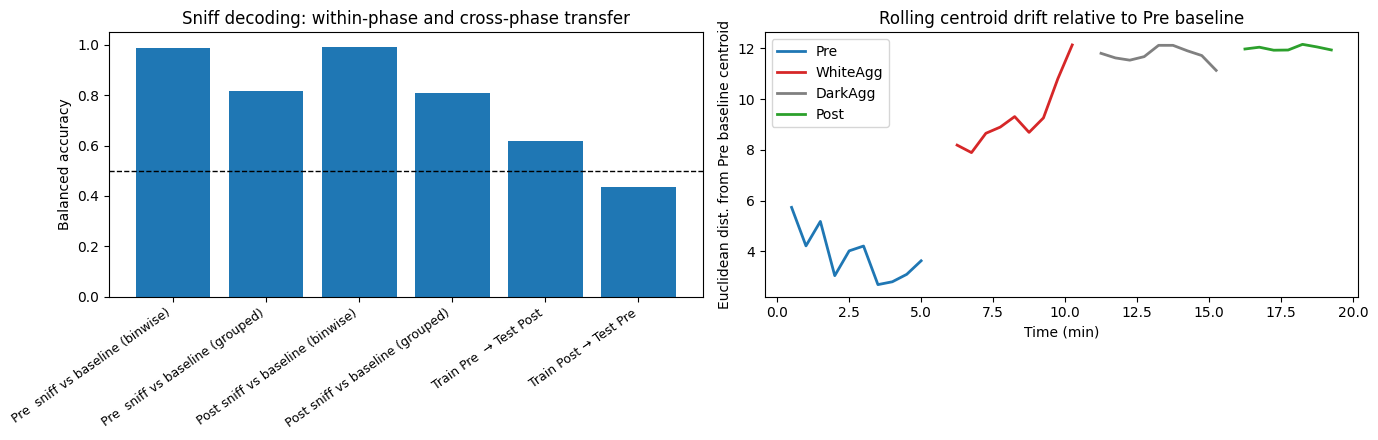

In [30]:
# Figures
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_df = sniff_dec_df.copy()
plot_df["metric"] = (plot_df["balanced_accuracy_mean"]
                     .fillna(plot_df["balanced_accuracy"]))
axes[0].bar(np.arange(len(plot_df)), plot_df["metric"])
axes[0].set_xticks(np.arange(len(plot_df)))
axes[0].set_xticklabels(plot_df["comparison"], rotation=35, ha="right", fontsize=9)
axes[0].axhline(0.5, color="k", ls="--", lw=1)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Balanced accuracy")
axes[0].set_title("Sniff decoding: within-phase and cross-phase transfer")

ph_cols = {"Pre": "tab:blue", "WhiteAgg": "tab:red",
           "DarkAgg": "gray",  "Post": "tab:green"}
for pnm in ["Pre", "WhiteAgg", "DarkAgg", "Post"]:
    sub = drift_df[drift_df["phase"] == pnm]
    if len(sub):
        axes[1].plot(sub["window_center_min"], sub["dist_to_pre_baseline"],
                     label=pnm, lw=2, color=ph_cols[pnm])
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("Euclidean dist. from Pre baseline centroid")
axes[1].set_title("Rolling centroid drift relative to Pre baseline")
axes[1].legend()

plt.tight_layout(); plt.show()

**Interpretation — Section 9**

*Strongest supported statement*: Pre → Post remapping is large and affects both the global population backbone and at least part of the local sniff-related modulation.

*Why this is stronger than a simple baseline-drift story*:
- Within-phase sniff decoding is strong in both Pre and Post.
- Cross-phase sniff transfer fails **explicitly** (not just as a missing value).
- The global Pre→Post baseline shift is large, but local sniff modulation vectors are also only partly aligned — so the change is not fully explained by baseline drift.

*Cannot rule out*: arousal/vigilance changes, adaptation, satiety, broader session non-stationarity.

*Interpretation*: session remapping — not proof of a specific learning mechanism.

## 10. Observer-side multiclass decoding (Pre & Post)

Test whether the three behavioural sub-states within Pre, and within Post, are
jointly separable — not just pairwise. This was present in the visual-final notebook
but absent from the revised version.

In [31]:
# =============================================================================
# SECTION 10 · Within-phase multiclass decoding
# Both binwise (reference) and grouped (conservative) reported.
# =============================================================================

# --- Binwise (reference, optimistic) ---
pre_state_dict = {
    "Pre_baseline": build_state_matrix(FRz, pre_baseline_mask),
    "Pre_sniff":    build_state_matrix(FRz, pre_sniff_mask),
    "Pre_milk":     build_state_matrix(FRz, pre_milk_mask),
}
post_state_dict = {
    "Post_baseline": build_state_matrix(FRz, post_baseline_mask),
    "Post_sniff":    build_state_matrix(FRz, post_sniff_mask),
    "Post_empty":    build_state_matrix(FRz, post_empty_mask),
}
pre_multi_bw,  pre_multi_cm_bw  = multiclass_cv(pre_state_dict,  n_splits=5, random_state=0)
post_multi_bw, post_multi_cm_bw = multiclass_cv(post_state_dict, n_splits=5, random_state=0)

# --- Grouped (conservative, chunk_len=50 bins = 1 s) ---
pre_mask_dict = {
    "Pre_baseline": pre_baseline_mask,
    "Pre_sniff":    pre_sniff_mask,
    "Pre_milk":     pre_milk_mask,
}
post_mask_dict = {
    "Post_baseline": post_baseline_mask,
    "Post_sniff":    post_sniff_mask,
    "Post_empty":    post_empty_mask,
}
pre_multi_gp,  pre_multi_cm_gp  = multiclass_cv_grouped(pre_mask_dict,  FRz, chunk_len=50, n_splits=5, random_state=0)
post_multi_gp, post_multi_cm_gp = multiclass_cv_grouped(post_mask_dict, FRz, chunk_len=50, n_splits=5, random_state=0)

# --- Print results ---
print("=" * 60)
print("Pre 3-way multiclass decoder:")
print(f"  Binwise:  {pre_multi_bw['balanced_accuracy_mean']:.3f} ± {pre_multi_bw['balanced_accuracy_std']:.3f}")
if pre_multi_gp:
    print(f"  Grouped:  {pre_multi_gp['balanced_accuracy_mean']:.3f} ± {pre_multi_gp['balanced_accuracy_std']:.3f}")

print()
print("Post 3-way multiclass decoder:")
print(f"  Binwise:  {post_multi_bw['balanced_accuracy_mean']:.3f} ± {post_multi_bw['balanced_accuracy_std']:.3f}")
if post_multi_gp:
    print(f"  Grouped:  {post_multi_gp['balanced_accuracy_mean']:.3f} ± {post_multi_gp['balanced_accuracy_std']:.3f}")
print("=" * 60)
print()
print("Note: binwise CV is optimistic (autocorrelation not fully removed).")
print("      grouped CV (1s chunks) is the conservative estimate.")
print("      Both are reported; grouped is preferred for PPT/paper.")

Pre 3-way multiclass decoder:
  Binwise:  0.982 ± 0.005
  Grouped:  0.845 ± 0.041

Post 3-way multiclass decoder:
  Binwise:  0.963 ± 0.012
  Grouped:  0.761 ± 0.086

Note: binwise CV is optimistic (autocorrelation not fully removed).
      grouped CV (1s chunks) is the conservative estimate.
      Both are reported; grouped is preferred for PPT/paper.


In [32]:
# Observer-side centroid geometry (6 conditions)
observer_centroids_dict = state_centroids(FRz, {
    "Pre_baseline":  pre_baseline_mask,
    "Pre_sniff":     pre_sniff_mask,
    "Pre_milk":      pre_milk_mask,
    "Post_baseline": post_baseline_mask,
    "Post_sniff":    post_sniff_mask,
    "Post_empty":    post_empty_mask,
})
obs_eu, obs_cos = pairwise_distance_tables(observer_centroids_dict)
print("Observer-side centroid Euclidean distances:"); display(obs_eu.round(3))

Observer-side centroid Euclidean distances:


,Pre_baseline,Pre_sniff,Pre_milk,Post_baseline,Post_sniff,Post_empty
Pre_baseline,0.0000,7.4050,9.1360,11.6600,12.3420,14.4080
Pre_sniff,7.4050,0.0000,10.8450,15.1810,14.0470,15.6130
Pre_milk,9.1360,10.8450,0.0000,16.0150,16.4170,15.5080
Post_baseline,11.6600,15.1810,16.0150,0.0000,5.7200,10.0560
Post_sniff,12.3420,14.0470,16.4170,5.7200,0.0000,10.7470
Post_empty,14.4080,15.6130,15.5080,10.0560,10.7470,0.0000


NameError: name 'pre_multi_cm' is not defined

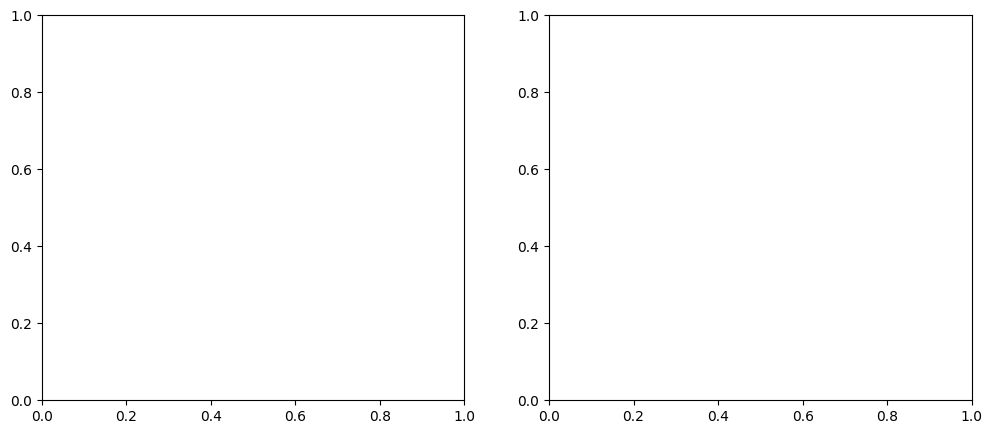

In [ ]:
# Confusion matrices — binwise (reference)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm_mat, title, names in [
    (axes[0], pre_multi_cm_bw,
     "Pre multiclass confusion (binwise)\n(baseline / sniff / milk)",
     list(pre_state_dict.keys())),
    (axes[1], post_multi_cm_bw,
     "Post multiclass confusion (binwise)\n(baseline / sniff / empty)",
     list(post_state_dict.keys())),
]:
    if cm_mat is not None:
        im = ax.imshow(cm_mat, aspect="auto", cmap="Blues")
        ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha="right")
        ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
        ax.set_title(title); plt.colorbar(im, ax=ax)
    else:
        ax.text(0.5, 0.5, "insufficient data",
                ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()

**Interpretation — Section 10**

- Within-phase multiclass decoding tests whether baseline, sniff, and milk/empty are jointly separable — a stricter test than pairwise binary decoding.
- Strong 3-way accuracy supports a richer within-phase observer-side state structure.
- Compare Pre and Post multiclass accuracy: if they are both high but the cross-phase binary decoder failed (Section 9), this confirms that the *structure* of within-phase coding is preserved but the *coordinates* have shifted.

## 11. Global session summary map & representational dissimilarity matrix

This is the most informative single visual in the analysis: all conditions projected
into one PCA space, plus the full-session RDM. Taken from the visual-final notebook.

In [ ]:
# =======================================================================
# SECTION 11 · All-condition centroid map + RDM  (完整独立版本)
# =======================================================================

# ── 重新定义所有条件 mask（包含之前漏掉的 milk 和 chase）──────────────
condition_masks_all = {
    # Pre phase
    "Pre_baseline": phase_masks["Pre"] & (~sniff_urine) & (~lick_milk) & (~lick_empty),
    "Pre_sniff":    phase_masks["Pre"] & sniff_urine,
    "Pre_milk":     phase_masks["Pre"] & lick_milk,

    # WhiteAgg phase
    "WA":           phase_masks["WhiteAgg"] & attack,
    "WN":           phase_masks["WhiteAgg"] & (~attack) & (~submission) & (~chase),
    "W_sub":        phase_masks["WhiteAgg"] & submission & (~attack),
    "W_chase":      phase_masks["WhiteAgg"] & chase & (~attack),

    # DarkAgg phase
    "DA":           phase_masks["DarkAgg"] & attack,
    "DN":           phase_masks["DarkAgg"] & (~attack),

    # Post phase
    "Post_baseline": phase_masks["Post"] & (~sniff_urine) & (~lick_milk) & (~lick_empty),
    "Post_sniff":    phase_masks["Post"] & sniff_urine,
    "Post_milk":     phase_masks["Post"] & lick_milk,
    "Post_empty":    phase_masks["Post"] & lick_empty,
}

# ── 打印各条件 bin 数，确认没有空条件 ──────────────────────────────────
print("Condition bin counts:")
for k, v in condition_masks_all.items():
    n = int(np.asarray(v).astype(bool).sum())
    flag = "  ← too few" if n < 50 else ""
    print(f"  {k:20s}: {n:6d} bins{flag}")

# ── 只保留 bin 数 >= 50 的条件进入分析 ─────────────────────────────────
MIN_BINS = 50
valid_masks = {
    k: np.asarray(v).astype(bool)
    for k, v in condition_masks_all.items()
    if int(np.asarray(v).astype(bool).sum()) >= MIN_BINS
}

print(f"\nConditions entering analysis (>= {MIN_BINS} bins): {list(valid_masks.keys())}")

# ── 计算质心并做 PCA ────────────────────────────────────────────────────
pca_summary, centroid_map_df = all_condition_centroid_map(
    FRz, valid_masks, min_samples=MIN_BINS, n_components=3
)
print("\nSummary PCA explained variance:", np.round(pca_summary.explained_variance_ratio_, 4))
display(centroid_map_df.round(3))

# ── 颜色映射（Pre=蓝系，White=红/紫系，Dark=橙系，Post=绿系）──────────
phase_color_map = {
    "Pre_baseline":  "#185FA5",   # 深蓝
    "Pre_sniff":     "#85B7EB",   # 浅蓝
    "Pre_milk":      "#B5D4F4",   # 更浅蓝

    "WA":            "#A32D2D",   # 深红
    "WN":            "#F09595",   # 浅红
    "W_sub":         "#7F77DD",   # 紫
    "W_chase":       "#D4537E",   # 粉紫（chase bin 少，可能不显示）

    "DA":            "#854F0B",   # 深橙
    "DN":            "#EF9F27",   # 浅橙

    "Post_baseline": "#085041",   # 深绿
    "Post_sniff":    "#1D9E75",   # 中绿
    "Post_milk":     "#9FE1CB",   # 浅绿
    "Post_empty":    "#5DCAA5",   # 薄荷绿
}

# ── 标注偏移：避免重叠 ─────────────────────────────────────────────────
label_offsets = {
    "Pre_baseline":  (7,   5),
    "Pre_sniff":     (7,  -12),
    "Pre_milk":      (7,   5),
    "WA":            (7,   5),
    "WN":            (7,  -12),
    "W_sub":         (-60, 5),
    "W_chase":       (7,   5),
    "DA":            (-52, 5),
    "DN":            (7,   5),
    "Post_baseline": (7,   5),
    "Post_sniff":    (7,  -12),
    "Post_milk":     (7,   5),
    "Post_empty":    (7,  -12),
}

# ── 计算 RDM ────────────────────────────────────────────────────────────
patterns_all = {
    k: condition_pattern(FRz, valid_masks[k])
    for k in valid_masks
}
rdm_cos = pattern_rdm(patterns_all, metric="cosine")
rdm_eu  = pattern_rdm(patterns_all, metric="euclidean")

# ── 画图 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：质心 PCA map
for nm, row in centroid_map_df.iterrows():
    col = phase_color_map.get(nm, "black")
    n_bins = valid_masks[nm].sum()
    # 点的大小按 log(bin数) 缩放，让 bin 少的条件点小一些
    size = max(60, min(200, 40 * np.log10(n_bins)))
    axes[0].scatter(row["PC1"], row["PC2"], s=size, color=col, zorder=5,
                    edgecolors="white", linewidths=0.5)
    dx, dy = label_offsets.get(nm, (7, 5))
    axes[0].annotate(nm, (row["PC1"], row["PC2"]),
                     textcoords="offset points", xytext=(dx, dy),
                     fontsize=8.5, color=col)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("All-condition centroid map  (shared PCA space)", fontsize=11)
axes[0].axhline(0, color="k", lw=0.4, ls=":")
axes[0].axvline(0, color="k", lw=0.4, ls=":")

# 右图：RDM
im = axes[1].imshow(rdm_cos.values, aspect="auto", cmap="viridis", vmin=0)
axes[1].set_xticks(range(len(rdm_cos.columns)))
axes[1].set_xticklabels(rdm_cos.columns, rotation=45, ha="right", fontsize=9)
axes[1].set_yticks(range(len(rdm_cos.index)))
axes[1].set_yticklabels(rdm_cos.index, fontsize=9)
axes[1].set_title("Representational Dissimilarity Matrix\n(cosine dissimilarity)", fontsize=11)
plt.colorbar(im, ax=axes[1], label="cosine dissimilarity")

plt.tight_layout()
plt.show()

# ── 打印关键距离数字（方便做 slide）──────────────────────────────────
print("\nKey Euclidean distances:")
key_pairs = [
    ("Pre_baseline", "Post_baseline"),
    ("Pre_sniff",    "Post_sniff"),
    ("WA",           "DA"),
    ("WA",           "WN"),
    ("WA",           "W_sub"),
    ("DA",           "DN"),
]
for a, b in key_pairs:
    if a in rdm_eu.index and b in rdm_eu.columns:
        d = rdm_eu.loc[a, b]
        print(f"  {a:18s} ↔ {b:18s}  d = {d:.3f}")

In [ ]:
print("Cosine RDM (full table):"); display(rdm_cos.round(3))
print("\nEuclidean RDM (full table):"); display(rdm_eu.round(3))

**Interpretation — Section 11**

The summary map and RDM together provide the global picture:
- Pre and Post conditions are distant from WhiteAgg/DarkAgg states → large phase remapping.
- WA and WN are well-separated within White; DA and DN within Dark.
- W_sub occupies a distinct position from WA within White.
- The RDM makes every pairwise representational distance explicit and numerically comparable.

**Use in discussion**: this is the single figure that best conveys the overall session geometry.
Present the map first ("here is where everything lives"), then zoom into individual sections for detail.

## 12. Compact summary tables

All key numerical results collected in one place.
Designed for use in discussion/interview without relying solely on figures.

In [ ]:
# =============================================================================
# SECTION 12 · All key numbers
# =============================================================================

summary_tables = {
    "01_attack_state_sizes":            attack_state_sizes,
    "02_attack_decoder":                attack_decode_df,
    "03_attack_WvsD_decoding":          wd_df,
    "04_attack_modulation_alignment":   attack_alignment_summary,
    "05_event_cleanliness":             event_clean_df,
    "06_event_early_displacement":      early_disp_df,
    "07_social_state_sizes":            social_state_sizes,
    "08_social_decoder":                atk_sub_df,
    "09_neuron_modulation_summary":     neuron_occ_df,
    "10_social_modulation_alignment":   sub_alignment_summary,
    "11_lr_state_sizes":                lr_sizes,
    "12_lr_decoding":                   lr_decoder_df,
    "13_observer_state_sizes":          observer_sizes_df,
    "14_sniff_decoder":                 sniff_dec_df,
    "15_vector_norms":                  vec_norms,
    "16_PR_tests":                      pr_df,
    "17_centroid_map":                  centroid_map_df,
    "18_rdm_cosine":                    rdm_cos,
}

for nm, df in summary_tables.items():
    print(f"\n{'='*65}\n{nm}")
    if isinstance(df, pd.DataFrame) and len(df) > 0:
        display(df.round(4))
    elif df is None or (isinstance(df, pd.DataFrame) and len(df) == 0):
        print("  (empty — insufficient data or analysis not run)")
    else:
        print(df)

## 13. Final discussion

### Findings that are reasonably robust at the descriptive level
1. **Attack is strongly separable within phase** — holds under both binwise and grouped CV in both White and Dark.
2. **White and Dark are strongly separable** even when matching attack/non-attack state → strong phase/context encoding beyond behaviour.
3. **White and Dark attack modulation vectors are only partly aligned** → context-dependent representation, not a single invariant code.
4. **Submission is a distinct White-phase population state** — separable from attack under grouped CV, with weakly aligned modulation vectors relative to the same White baseline.
5. **Pre → Post remapping is the largest session-scale effect** — affects both global population backbone and at least part of the local sniff-related coding; cross-phase sniff transfer fails explicitly.

### Findings that should still be presented as cautious interpretations
- Left/right visual field may contribute to some White-phase social structure (check Section 8 results before discussing).
- Attack trajectories reflect **clustered episode dynamics**, not isolated attack transients (see event cleanliness table, Section 6).
- Pre → Post remapping is not reducible to baseline drift alone, but the specific cause (learning, arousal, adaptation, satiety, non-stationarity) remains open.

### Claims to avoid
- "This notebook identifies the aggression circuit / mechanism."
- "Submission and attack are proven to arise from distinct biological circuits."
- "Post sniff remapping proves associative learning."
- "Grouped CV fully solves temporal dependence."

---

### Recommended oral phrasing for discussion
> "This dataset shows that brain-wide population activity is strongly organised by
> behavioural phase and social context. Attack is highly separable within phase,
> but its modulation is only partly conserved across White and Dark, suggesting
> context-dependent remapping rather than a single invariant code. Submission occupies
> a distinct White-phase population state. The largest session-scale effect is the
> Pre-to-Post remapping, which affects both the global population backbone and at
> least part of the local sniff-related coding."

---

### Suggested 40-minute discussion structure
1. **Attack is strong but context-dependent** — Section 5 decoding + vector alignment
2. **Cross-phase asymmetry: White vs Dark attack effects only weakly aligned** — Section 5
3. **Attack trajectories reflect clustered episodes, not isolated events** — Section 6 cleanliness table + speed curves
4. **Submission is a distinct White-phase social state** — Section 7 PCA + decoder + per-neuron
5. **(Optional) Left/right check** — Section 8: does the structure survive spatial control?
6. **Pre → Post remapping is the largest effect** — Section 9 cross-phase decoder failure
7. **Observer-side structure reveals the texture of that remapping** — Section 10 multiclass + Section 11 map
8. **Use the summary map / RDM as supporting geometry throughout** — Section 11